### EDA - REGISTRO VENTAS FARMACIA ###

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/farmacia-datos.csv", sep=";", encoding="latin1")
df.head(20)

,Fecha,Tipo Mov.,Fac. Tipo,Fac. Suc.,Fac. Nun.,Fisc. Numero,Tipo Pago,Cant.,Precio,Producto,Sub. Total,Rubro,Cobertura,Ajustes,Desc. Adic.,Total. Cliente,IVA,Tasa Iva,Total Gravado,Total sin Gravar
0,01/01/25 01.13.46,F,B,0,379923,NaN,E,1,9344,ACTRON PEDIATRICO 4% susp.oral x 100 ml,9344,FARMACIA,0,0,0,9344,0,0,0,9344
1,01/01/25 01.59.21,F,B,0,379924,NaN,E,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"3032,85",0,0,"5142,11",0,0,0,"8174,96"
2,01/01/25 02.01.59,F,B,0,379925,NaN,E,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"5318,1",0,0,"2856,86",0,0,0,"8174,96"
3,01/01/25 02.04.14,F,B,0,379926,NaN,E,1,"8086,82",MUELITA FORTE GEL gel pomo x 10 g,"8086,82",FARMACIA,0,0,0,"8086,82",0,0,0,"8086,82"
4,01/01/25 02.08.35,F,B,0,379927,NaN,E,1,"26750,12",DIOXAFLEX B12 comp.x 20,"26750,12",FARMACIA,0,0,0,"26750,12",0,0,0,"26750,12"
5,01/01/25 06.06.42,F,B,0,379928,NaN,E,1,"24480,51",EVATEST DIGITAL env.x 1,"24480,51",FARMACIA,0,0,0,"24480,51","4248,683554",21,"20231,82645",0
6,01/01/25 06.22.37,F,B,0,379929,NaN,E,1,4800,GEN LP KETOROLAC blister 20 mg x 10,4800,FARMACIA,0,0,0,4800,0,0,0,4800
7,01/01/25 06.22.37,F,B,0,379929,NaN,E,1,4961,CAFIASPIRINA PLUS comp.x 20,4961,FARMACIA,0,0,0,4961,0,0,0,4961
8,01/01/25 07.46.36,F,B,0,379930,NaN,E,2,3500,ACCESORIO (unica),7000,FARMACIA,0,0,0,7000,"1214,876033",21,"5785,123967",0
9,02/01/25 08.08.38,F,B,0,379931,NaN,E,1,3430,QURA PLUS comp.rec.x 20,3430,FARMACIA,0,0,343,3087,0,0,0,3430


In [3]:
df.info(), df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117415 entries, 0 to 117414
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Fecha             117415 non-null  object 
 1   Tipo Mov.         117415 non-null  object 
 2   Fac. Tipo         117415 non-null  object 
 3   Fac. Suc.         117415 non-null  int64  
 4   Fac. Nun.         117415 non-null  int64  
 5   Fisc. Numero      0 non-null       float64
 6   Tipo Pago         117415 non-null  object 
 7   Cant.             117415 non-null  int64  
 8   Precio            117415 non-null  object 
 9   Producto          117414 non-null  object 
 10  Sub. Total        117415 non-null  object 
 11  Rubro             117415 non-null  object 
 12  Cobertura         117415 non-null  object 
 13  Ajustes           117415 non-null  int64  
 14  Desc. Adic.       117415 non-null  object 
 15  Total. Cliente    117415 non-null  object 
 16  IVA               11

(None, (117415, 20))

In [4]:
df.columns

Index(['Fecha', 'Tipo Mov.', 'Fac. Tipo', 'Fac. Suc.', 'Fac. Nun.',
       'Fisc. Numero', 'Tipo Pago', 'Cant.', 'Precio', 'Producto',
       'Sub. Total', 'Rubro', 'Cobertura', 'Ajustes', 'Desc. Adic.',
       'Total. Cliente', 'IVA', 'Tasa Iva', 'Total Gravado',
       'Total sin Gravar'],
      dtype='object')

In [6]:
List_num = df.select_dtypes(include=['float64','int64']).columns.tolist()
List_num

['Fac. Suc.', 'Fac. Nun.', 'Fisc. Numero', 'Cant.', 'Ajustes', 'Tasa Iva']

In [7]:
cols_float = ['Fac. Suc.', 'Fac. Nun.', 'Cant.','Precio', 'Sub. Total', 'Cobertura', 'Ajustes','Desc. Adic.', 'IVA', 'Tasa Iva','Total Gravado']

In [8]:
df[cols_float] = (df[cols_float].astype(str).replace(r'\.', '', regex=True).replace(',', '.', regex=True).apply(pd.to_numeric, errors='coerce'))

In [9]:
df[cols_float].dtypes

Fac. Suc.          int64
Fac. Nun.          int64
Cant.              int64
Precio           float64
Sub. Total       float64
Cobertura        float64
Ajustes            int64
Desc. Adic.      float64
IVA              float64
Tasa Iva           int64
Total Gravado    float64
dtype: object

In [10]:
df['Total sin Gravar'].head(5)

0        9344
1     8174,96
2     8174,96
3     8086,82
4    26750,12
Name: Total sin Gravar, dtype: object

In [11]:
df['Total. Cliente'].head(5)

0        9344
1     5142,11
2     2856,86
3     8086,82
4    26750,12
Name: Total. Cliente, dtype: object

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117415 entries, 0 to 117414
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Fecha             117415 non-null  object 
 1   Tipo Mov.         117415 non-null  object 
 2   Fac. Tipo         117415 non-null  object 
 3   Fac. Suc.         117415 non-null  int64  
 4   Fac. Nun.         117415 non-null  int64  
 5   Fisc. Numero      0 non-null       float64
 6   Tipo Pago         117415 non-null  object 
 7   Cant.             117415 non-null  int64  
 8   Precio            117415 non-null  float64
 9   Producto          117414 non-null  object 
 10  Sub. Total        117415 non-null  float64
 11  Rubro             117415 non-null  object 
 12  Cobertura         117415 non-null  float64
 13  Ajustes           117415 non-null  int64  
 14  Desc. Adic.       117415 non-null  float64
 15  Total. Cliente    117415 non-null  object 
 16  IVA               11

In [13]:
df.duplicated().sum()

np.int64(121)

In [14]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Fac. Suc.,117415.0,0.00,0.00,0.00,0.0,0.00,0.00,0.00
Fac. Nun.,117415.0,417643.59,22420.16,379923.00,398031.0,416281.00,437618.50,455865.00
Fisc. Numero,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cant.,117415.0,1.37,1.86,0.00,1.0,1.00,1.00,106.00
Precio,117415.0,16421.45,19078.33,0.00,5700.0,11269.23,21433.53,760983.88
Sub. Total,117415.0,17387.68,30548.13,0.00,5740.0,11281.07,21938.31,3377910.00
Cobertura,117415.0,7755.71,26465.17,-157953.92,0.0,0.00,9929.95,3217060.00
Ajustes,117415.0,0.00,0.00,0.00,0.0,0.00,0.00,0.00
Desc. Adic.,117415.0,76.55,1109.67,-31312.40,0.0,0.00,0.00,64474.40
IVA,117415.0,364.14,4038.84,0.00,0.0,0.00,0.00,586248.84


In [15]:
df.isnull().sum()

Fecha                    0
Tipo Mov.                0
Fac. Tipo                0
Fac. Suc.                0
Fac. Nun.                0
Fisc. Numero        117415
Tipo Pago                0
Cant.                    0
Precio                   0
Producto                 1
Sub. Total               0
Rubro                    0
Cobertura                0
Ajustes                  0
Desc. Adic.              0
Total. Cliente           0
IVA                      0
Tasa Iva                 0
Total Gravado            0
Total sin Gravar         0
dtype: int64

In [16]:
df.drop(['Fisc. Numero'],axis=1,inplace=True)

In [17]:
df['Producto'] = df['Producto'].str.lower()

In [18]:
df['Producto'].nunique()

7671

In [19]:
df['Tasa Iva'].value_counts()

Tasa Iva
0     94545
21    22870
Name: count, dtype: int64

In [20]:
df['Producto'].value_counts()

Producto
gen lp ibuprofeno blister 600 mg x 10      1926
gen lp omeprazol blister 20 mg x 15        1205
aspirina prevent comp.cub.enterica x 50    1150
tafirol 1g x 8 (unica)                      870
tafirol 1 g comp.ran.x 50                   699
                                           ... 
probiomax pvo. sob. x 15                      1
artrait 2.5 mg comp.x 20                      1
dutasinar 0.5 mg comp.x 30                    1
ensure advance frutilla lata x 400 g          1
cod liver oil cáps.x 60                       1
Name: count, Length: 7671, dtype: int64

In [21]:
df['Producto'].str.contains('unica', case=False, na=False).sum()

np.int64(7449)

In [22]:
df['Producto'].str.contains('gen', case=False, na=False).sum()

np.int64(8619)

In [23]:
df['Producto'].str.contains('ibu', case=False, na=False).sum()

np.int64(5100)

In [24]:
df[['Producto', 'Precio']].drop_duplicates().shape[0]

37731

In [25]:
df['Producto'].value_counts().head(25)

Producto
gen lp ibuprofeno blister 600 mg x 10                          1926
gen lp omeprazol blister 20 mg x 15                            1205
aspirina prevent comp.cub.enterica x 50                        1150
tafirol 1g x 8 (unica)                                          870
tafirol 1 g comp.ran.x 50                                       699
osteodyn sol.oral x 2 ml                                        605
refenax gts.nasales x 25 ml                                     543
gen lp diclofenac blister 75 mg x 15                            530
gen lp diclofenac pridinol blister x 15                         488
acc lp gasa esteril no 5 caja 10 x 10                           473
corbis 5 mg comp.rec.x 30                                       471
tafirol plus rapida accion cáps.bl. x 8                         471
alikal (unica)                                                  451
t4 montpellier 75 75 mcg comp.x 50                              446
acc lp tela antialergica 3m de 2.5 x 9 

concepto por mes de ventas, logica de negocio mas EDA

In [26]:
df['Fecha']

0         01/01/25 01.13.46
1         01/01/25 01.59.21
2         01/01/25 02.01.59
3         01/01/25 02.04.14
4         01/01/25 02.08.35
                ...        
117410    23/12/25 10.23.06
117411    23/12/25 10.25.57
117412    23/12/25 10.34.31
117413    23/12/25 10.38.49
117414    23/12/25 10.53.40
Name: Fecha, Length: 117415, dtype: object

In [27]:
df['Fecha'] = pd.to_datetime(df['Fecha'],format='%d/%m/%y %H.%M.%S',errors='coerce')

In [28]:
df['Fecha'] = pd.to_datetime(df['Fecha'])

In [29]:
df['Mes'] = df['Fecha'].dt.to_period('M')

In [30]:
df['Día'] = df['Fecha'].dt.day


In [31]:
df['Fecha']

0        2025-01-01 01:13:46
1        2025-01-01 01:59:21
2        2025-01-01 02:01:59
3        2025-01-01 02:04:14
4        2025-01-01 02:08:35
                 ...        
117410   2025-12-23 10:23:06
117411   2025-12-23 10:25:57
117412   2025-12-23 10:34:31
117413   2025-12-23 10:38:49
117414   2025-12-23 10:53:40
Name: Fecha, Length: 117415, dtype: datetime64[ns]

In [32]:
df['Mes']

0         2025-01
1         2025-01
2         2025-01
3         2025-01
4         2025-01
           ...   
117410    2025-12
117411    2025-12
117412    2025-12
117413    2025-12
117414    2025-12
Name: Mes, Length: 117415, dtype: period[M]

In [33]:
df['Día']

0          1
1          1
2          1
3          1
4          1
          ..
117410    23
117411    23
117412    23
117413    23
117414    23
Name: Día, Length: 117415, dtype: int32

In [34]:
ventas = (df.groupby(['Mes', 'Producto'])['Cant.'].sum().reset_index())

In [35]:
top_5_mensual = (ventas.sort_values(['Mes', 'Cant.'], ascending=[True, False]).groupby('Mes').head(5))

In [36]:
top_5_mensual

,Mes,Producto,Cant.
498,2025-01,buscapina compositum comp.rec.x 20,383
2587,2025-01,sertal compuesto comp.rec.x 20,260
1367,2025-01,gen lp ibuprofeno blister 600 mg x 10,210
1917,2025-01,migral 500 mg comp.x 100,210
1377,2025-01,gen lp omeprazol blister 20 mg x 15,163
3498,2025-02,buscapina compositum comp.rec.x 20,252
4324,2025-02,gen lp ibuprofeno blister 600 mg x 10,190
5326,2025-02,qura plus comp.rec.x 20,186
5518,2025-02,sertal compuesto comp.rec.x 20,182
4333,2025-02,gen lp omeprazol blister 20 mg x 15,152


In [37]:
ventas_mensuales = (df.groupby(['Mes', 'Producto'], as_index=False)['Cant.'].sum())

In [38]:
top_100_mensual = (ventas_mensuales.sort_values(['Mes', 'Cant.'], ascending=[True, False]).groupby('Mes').head(100))

In [39]:
top_100_mensual

,Mes,Producto,Cant.
498,2025-01,buscapina compositum comp.rec.x 20,383
2587,2025-01,sertal compuesto comp.rec.x 20,260
1367,2025-01,gen lp ibuprofeno blister 600 mg x 10,210
1917,2025-01,migral 500 mg comp.x 100,210
1377,2025-01,gen lp omeprazol blister 20 mg x 15,163
...,...,...,...
34709,2025-12,macril cr.x 20 g,15
35500,2025-12,tafirol comp. x 10,15
33099,2025-12,acc lp guantes latex par,14
33234,2025-12,alplax 0.50 mg comp.x 60,14


In [40]:
enero = df[df['Mes'] == '2025-01']

In [41]:
top_enero = top_100_mensual[top_100_mensual['Mes'] == '2025-01']

In [42]:
top_enero

,Mes,Producto,Cant.
498,2025-01,buscapina compositum comp.rec.x 20,383
2587,2025-01,sertal compuesto comp.rec.x 20,260
1367,2025-01,gen lp ibuprofeno blister 600 mg x 10,210
1917,2025-01,migral 500 mg comp.x 100,210
1377,2025-01,gen lp omeprazol blister 20 mg x 15,163
...,...,...,...
358,2025-01,bagohepat comp.rec.x 40,22
2716,2025-01,tafirol comp.x 30,22
36,2025-01,acc lp jeringa descart con aguja 3 cc 40/80,21
62,2025-01,accesorio carey (unica),21


In [43]:
df['Producto'] = df['Producto'].str.strip().str.lower()
df['Mes'] = df['Fecha'].dt.to_period('M')

ventas = (df.groupby(['Mes', 'Producto'], as_index=False)['Cant.'].sum())

ventas['rank'] = ventas.groupby('Mes')['Cant.'].rank(method='first',ascending=False)

top_100_por_mes = ventas[ventas['rank'] <= 100].sort_values(['Mes', 'rank'])

top_100_por_mes = top_100_por_mes.reset_index(drop=True)

In [44]:
top_100_por_mes.head(20)

,Mes,Producto,Cant.,rank
0,2025-01,buscapina compositum comp.rec.x 20,383,1.0
1,2025-01,sertal compuesto comp.rec.x 20,260,2.0
2,2025-01,gen lp ibuprofeno blister 600 mg x 10,210,3.0
3,2025-01,migral 500 mg comp.x 100,210,4.0
4,2025-01,gen lp omeprazol blister 20 mg x 15,163,5.0
5,2025-01,tafirol 1 g comp.ran.x 24,156,6.0
6,2025-01,mylanta extra comp.mast.x 24,155,7.0
7,2025-01,alikal (unica),143,8.0
8,2025-01,ensure advance liquido frutilla bot. x 220 ml,120,9.0
9,2025-01,bayaspirina comp.x 30,113,10.0


<Figure size 1200x800 with 0 Axes>

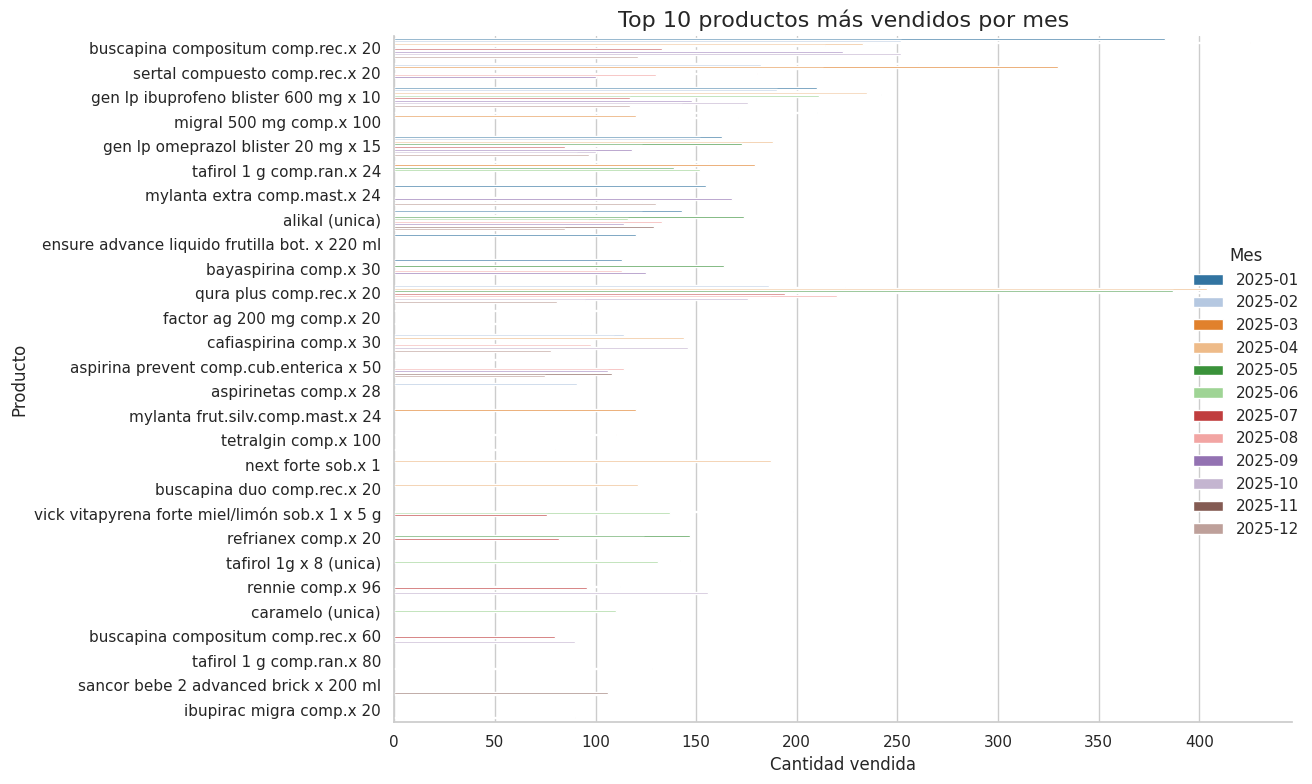

In [45]:
top_10_por_mes = top_100_por_mes[top_100_por_mes['rank'] <= 10]

# Ajustes de estilo
sns.set(style="whitegrid")
plt.figure(figsize=(12, 8))

# Creamos gráfico de barras, separando por mes
g = sns.catplot(
    data=top_10_por_mes,
    x='Cant.', 
    y='Producto', 
    hue='Mes',
    kind='bar',
    height=8, 
    aspect=1.5,
    palette="tab20")

plt.title("Top 10 productos más vendidos por mes", fontsize=16)
plt.xlabel("Cantidad vendida", fontsize=12)
plt.ylabel("Producto", fontsize=12)
plt.tight_layout()

plt.show()

/tmp/ipykernel_2168/3632361701.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


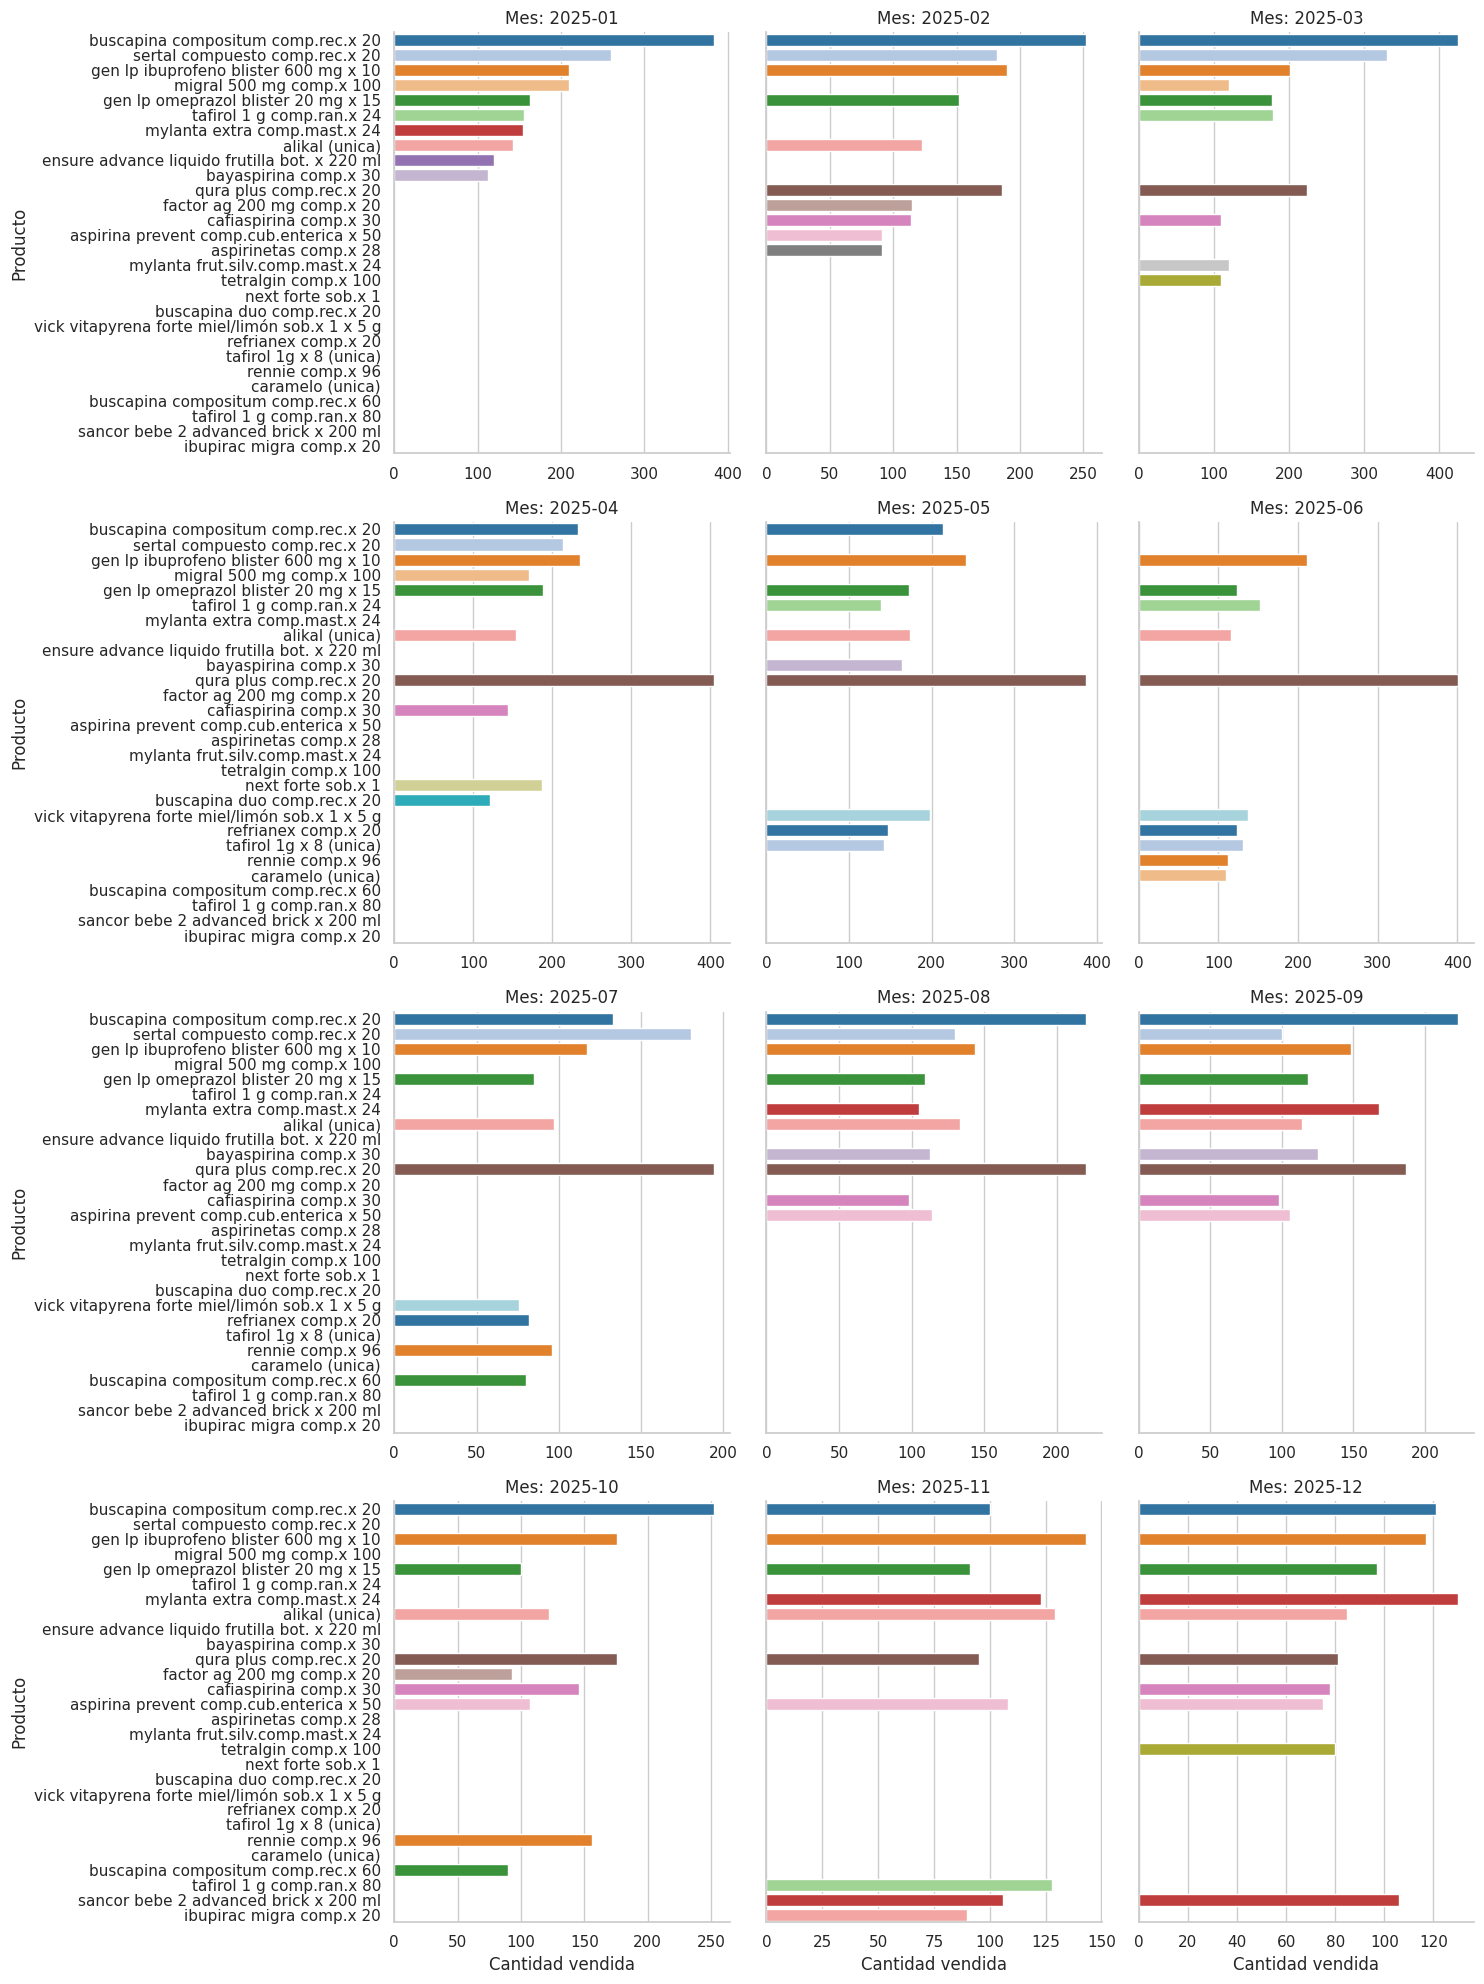

In [46]:
g = sns.catplot(
    data=top_10_por_mes,
    x='Cant.',
    y='Producto',
    col='Mes',
    kind='bar',
    col_wrap=3,
    height=5,
    sharex=False,
    palette="tab20"
)
g.set_titles("Mes: {col_name}")
g.set_axis_labels("Cantidad vendida", "Producto")
plt.tight_layout()
plt.show()


In [47]:
# Pivot table de ventas
ventas_pivot = top_100_por_mes.pivot_table(
    index='Producto',
    columns='Mes',
    values='Cant.',
    aggfunc='sum',
    fill_value=0)

# Calcular ventas totales por producto
ventas_pivot['Total'] = ventas_pivot.sum(axis=1)

# Seleccionar los top 30 productos
top30_productos = ventas_pivot.sort_values('Total', ascending=False).head(30).drop('Total', axis=1)


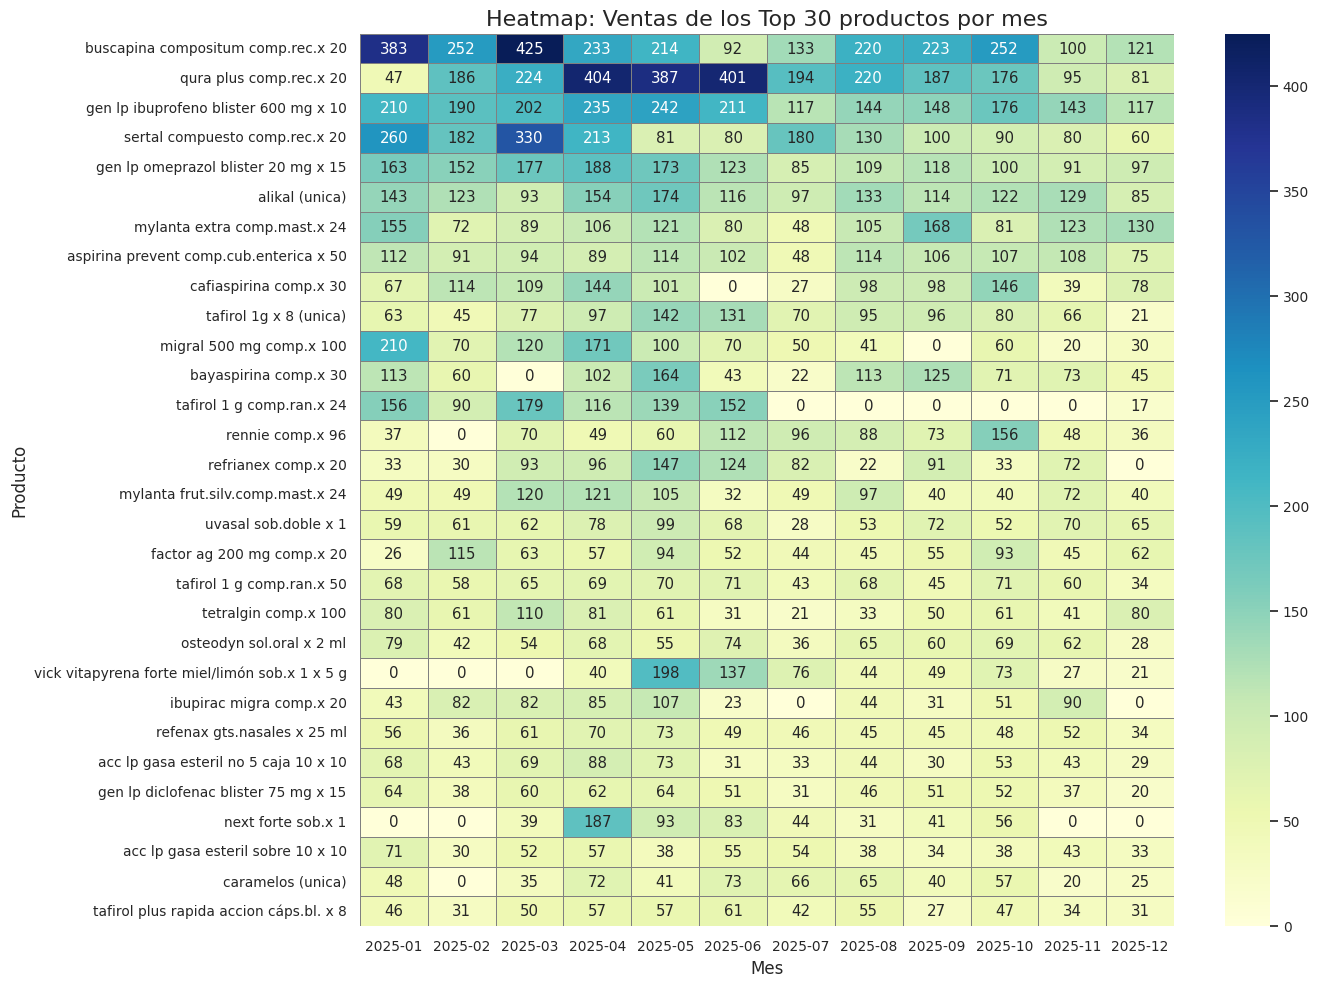

In [48]:
plt.figure(figsize=(14, 10))
sns.set(font_scale=0.9)

sns.heatmap(top30_productos,cmap="YlGnBu",linewidths=0.5,linecolor='gray',annot=True,fmt=".0f")

plt.title("Heatmap: Ventas de los Top 30 productos por mes", fontsize=16)
plt.xlabel("Mes", fontsize=12)
plt.ylabel("Producto", fontsize=12)
plt.tight_layout()
plt.show()


In [49]:
df["presentacion"] = df["Producto"].copy()

In [50]:
df['presentacion'] = df['presentacion'].astype(str)

In [51]:
df['presentacion']

0         actron pediatrico 4% susp.oral x 100 ml
1                   amoxidal 500 mg comp.rec.x 21
2                   amoxidal 500 mg comp.rec.x 21
3               muelita forte gel gel pomo x 10 g
4                         dioxaflex b12 comp.x 20
                           ...                   
117410                            colgate (unica)
117411                  tafirol 1 g comp.ran.x 50
117412              cicatricure gel gel nf x 30 g
117413                  louten t colirio x 2.5 ml
117414               madopar hbs 125 mg cáps.x 30
Name: presentacion, Length: 117415, dtype: object

In [52]:
df['presentacion'].value_counts().head(10)

presentacion
gen lp ibuprofeno blister 600 mg x 10      1926
gen lp omeprazol blister 20 mg x 15        1205
aspirina prevent comp.cub.enterica x 50    1150
tafirol 1g x 8 (unica)                      870
tafirol 1 g comp.ran.x 50                   699
osteodyn sol.oral x 2 ml                    605
refenax gts.nasales x 25 ml                 543
gen lp diclofenac blister 75 mg x 15        530
gen lp diclofenac pridinol blister x 15     488
acc lp gasa esteril no 5 caja 10 x 10       473
Name: count, dtype: int64

In [53]:
df['presentacion'].str.contains('ibupirac 600 caps', case=False, na=False).sum()

np.int64(713)

In [54]:
# Filtrar filas que contienen 'ibu' (ignorando mayúsculas/minúsculas)
filas_que_contienen_ibu = df.loc[df['presentacion'].str.contains('ibupirac 600 caps', case=False, na=False), 'presentacion']

# Contar cuántos valores distintos hay
cantidad_distintos = filas_que_contienen_ibu.nunique()

print("Cantidad de valores distintos que contienen 'ibu':", cantidad_distintos)

# Opcional: ver cuáles son los distintos
valores_distintos = filas_que_contienen_ibu.unique()
print(valores_distintos)


Cantidad de valores distintos que contienen 'ibu': 3
['ibupirac 600 capsula blanda cáps.blandas x 20'
 'ibupirac 600 capsula blanda cáps.blandas x 10'
 'ibupirac 600 capsula blanda cáps.blandas x 50']


In [55]:
df.columns

Index(['Fecha', 'Tipo Mov.', 'Fac. Tipo', 'Fac. Suc.', 'Fac. Nun.',
       'Tipo Pago', 'Cant.', 'Precio', 'Producto', 'Sub. Total', 'Rubro',
       'Cobertura', 'Ajustes', 'Desc. Adic.', 'Total. Cliente', 'IVA',
       'Tasa Iva', 'Total Gravado', 'Total sin Gravar', 'Mes', 'Día',
       'presentacion'],
      dtype='object')

In [56]:
df

,Fecha,Tipo Mov.,Fac. Tipo,Fac. Suc.,Fac. Nun.,Tipo Pago,Cant.,Precio,Producto,Sub. Total,...,Ajustes,Desc. Adic.,Total. Cliente,IVA,Tasa Iva,Total Gravado,Total sin Gravar,Mes,Día,presentacion
0,2025-01-01 01:13:46,F,B,0,379923,E,1,9344.00,actron pediatrico 4% susp.oral x 100 ml,9344.00,...,0,0.0,9344,0.000000,0,0.0000,9344,2025-01,1,actron pediatrico 4% susp.oral x 100 ml
1,2025-01-01 01:59:21,F,B,0,379924,E,1,8174.96,amoxidal 500 mg comp.rec.x 21,8174.96,...,0,0.0,"5142,11",0.000000,0,0.0000,"8174,96",2025-01,1,amoxidal 500 mg comp.rec.x 21
2,2025-01-01 02:01:59,F,B,0,379925,E,1,8174.96,amoxidal 500 mg comp.rec.x 21,8174.96,...,0,0.0,"2856,86",0.000000,0,0.0000,"8174,96",2025-01,1,amoxidal 500 mg comp.rec.x 21
3,2025-01-01 02:04:14,F,B,0,379926,E,1,8086.82,muelita forte gel gel pomo x 10 g,8086.82,...,0,0.0,"8086,82",0.000000,0,0.0000,"8086,82",2025-01,1,muelita forte gel gel pomo x 10 g
4,2025-01-01 02:08:35,F,B,0,379927,E,1,26750.12,dioxaflex b12 comp.x 20,26750.12,...,0,0.0,"26750,12",0.000000,0,0.0000,"26750,12",2025-01,1,dioxaflex b12 comp.x 20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117410,2025-12-23 10:23:06,F,B,0,455861,E,1,5000.00,colgate (unica),5000.00,...,0,0.0,5000,0.000000,0,0.0000,5000,2025-12,23,colgate (unica)
117411,2025-12-23 10:25:57,F,B,0,455862,E,1,13641.20,tafirol 1 g comp.ran.x 50,13641.20,...,0,0.0,"7832,22",0.000000,0,0.0000,"13641,2",2025-12,23,tafirol 1 g comp.ran.x 50
117412,2025-12-23 10:34:31,F,B,0,455863,E,1,16000.00,cicatricure gel gel nf x 30 g,16000.00,...,0,0.0,16000,2776.859504,21,13223.1405,0,2025-12,23,cicatricure gel gel nf x 30 g
117413,2025-12-23 10:38:49,F,B,0,455864,E,1,36758.39,louten t colirio x 2.5 ml,36758.39,...,0,0.0,"22055,03",0.000000,0,0.0000,"36758,39",2025-12,23,louten t colirio x 2.5 ml


In [57]:
df['Total sin Gravar'].sum()


'93448174,968174,968086,8226750,120480049610343035517,323864,218160,940008008922,38012424,4100350055873,915294,56045296,3760074,0200509453605600174703236,5716123,5715892,6117409,8718896,0127831,8916997,634800051353,4128932,07012181,334373022441,2911790,8825502800450002300380013295,2423913,278876,5223646,7337426,4676234,1225000,020026789,8536287,3625638,8631175,7719728,73067297,2627234,8811952,886484,510030005688,189323,9413367,5503907000290067002208961063253,7653565,0550769,9719562,1631626,8829397,441221732267,2635215,315332,5930419477,7617139,6234279,2440018,280210072000007596,80043727,450060361,3830843,0450509,6830679,175995,665332,519232,2512538,7317139,6212364,6731044,678870,0760006121,437677,96300027923,4717251,2421007661,29112057,3939669,5234716,7104509043,3853565,0528316,84350058166,99010381,7121818,87918,7427234,887918,7456200,3120545,9317468,040011594,3316275,996404,5460031148,8327926,824827,357918,748870,070989939343,47149011385,5237180,03010627010705,1624394,952785,3123315,3

In [58]:
df.head(10)

,Fecha,Tipo Mov.,Fac. Tipo,Fac. Suc.,Fac. Nun.,Tipo Pago,Cant.,Precio,Producto,Sub. Total,...,Ajustes,Desc. Adic.,Total. Cliente,IVA,Tasa Iva,Total Gravado,Total sin Gravar,Mes,Día,presentacion
0,2025-01-01 01:13:46,F,B,0,379923,E,1,9344.00,actron pediatrico 4% susp.oral x 100 ml,9344.00,...,0,0.0,9344,0.000000,0,0.000000,9344,2025-01,1,actron pediatrico 4% susp.oral x 100 ml
1,2025-01-01 01:59:21,F,B,0,379924,E,1,8174.96,amoxidal 500 mg comp.rec.x 21,8174.96,...,0,0.0,"5142,11",0.000000,0,0.000000,"8174,96",2025-01,1,amoxidal 500 mg comp.rec.x 21
2,2025-01-01 02:01:59,F,B,0,379925,E,1,8174.96,amoxidal 500 mg comp.rec.x 21,8174.96,...,0,0.0,"2856,86",0.000000,0,0.000000,"8174,96",2025-01,1,amoxidal 500 mg comp.rec.x 21
3,2025-01-01 02:04:14,F,B,0,379926,E,1,8086.82,muelita forte gel gel pomo x 10 g,8086.82,...,0,0.0,"8086,82",0.000000,0,0.000000,"8086,82",2025-01,1,muelita forte gel gel pomo x 10 g
4,2025-01-01 02:08:35,F,B,0,379927,E,1,26750.12,dioxaflex b12 comp.x 20,26750.12,...,0,0.0,"26750,12",0.000000,0,0.000000,"26750,12",2025-01,1,dioxaflex b12 comp.x 20
5,2025-01-01 06:06:42,F,B,0,379928,E,1,24480.51,evatest digital env.x 1,24480.51,...,0,0.0,"24480,51",4248.683554,21,20231.826450,0,2025-01,1,evatest digital env.x 1
6,2025-01-01 06:22:37,F,B,0,379929,E,1,4800.00,gen lp ketorolac blister 20 mg x 10,4800.00,...,0,0.0,4800,0.000000,0,0.000000,4800,2025-01,1,gen lp ketorolac blister 20 mg x 10
7,2025-01-01 06:22:37,F,B,0,379929,E,1,4961.00,cafiaspirina plus comp.x 20,4961.00,...,0,0.0,4961,0.000000,0,0.000000,4961,2025-01,1,cafiaspirina plus comp.x 20
8,2025-01-01 07:46:36,F,B,0,379930,E,2,3500.00,accesorio (unica),7000.00,...,0,0.0,7000,1214.876033,21,5785.123967,0,2025-01,1,accesorio (unica)
9,2025-01-02 08:08:38,F,B,0,379931,E,1,3430.00,qura plus comp.rec.x 20,3430.00,...,0,343.0,3087,0.000000,0,0.000000,3430,2025-01,2,qura plus comp.rec.x 20


In [59]:
df['Total sin Gravar'].head(20)

0         9344
1      8174,96
2      8174,96
3      8086,82
4     26750,12
5            0
6         4800
7         4961
8            0
9         3430
10     35517,3
11    23864,21
12     8160,94
13           0
14           0
15           0
16         800
17     8922,38
18           0
19    12424,41
Name: Total sin Gravar, dtype: object

In [60]:
df.head(5)

,Fecha,Tipo Mov.,Fac. Tipo,Fac. Suc.,Fac. Nun.,Tipo Pago,Cant.,Precio,Producto,Sub. Total,...,Ajustes,Desc. Adic.,Total. Cliente,IVA,Tasa Iva,Total Gravado,Total sin Gravar,Mes,Día,presentacion
0,2025-01-01 01:13:46,F,B,0,379923,E,1,9344.00,actron pediatrico 4% susp.oral x 100 ml,9344.00,...,0,0.0,9344,0.0,0,0.0,9344,2025-01,1,actron pediatrico 4% susp.oral x 100 ml
1,2025-01-01 01:59:21,F,B,0,379924,E,1,8174.96,amoxidal 500 mg comp.rec.x 21,8174.96,...,0,0.0,"5142,11",0.0,0,0.0,"8174,96",2025-01,1,amoxidal 500 mg comp.rec.x 21
2,2025-01-01 02:01:59,F,B,0,379925,E,1,8174.96,amoxidal 500 mg comp.rec.x 21,8174.96,...,0,0.0,"2856,86",0.0,0,0.0,"8174,96",2025-01,1,amoxidal 500 mg comp.rec.x 21
3,2025-01-01 02:04:14,F,B,0,379926,E,1,8086.82,muelita forte gel gel pomo x 10 g,8086.82,...,0,0.0,"8086,82",0.0,0,0.0,"8086,82",2025-01,1,muelita forte gel gel pomo x 10 g
4,2025-01-01 02:08:35,F,B,0,379927,E,1,26750.12,dioxaflex b12 comp.x 20,26750.12,...,0,0.0,"26750,12",0.0,0,0.0,"26750,12",2025-01,1,dioxaflex b12 comp.x 20


In [61]:
# Quitar espacios y unificar comas decimales
df['Total sin Gravar'] = (
    df['Total sin Gravar']
    .astype(str)
    .str.replace('.', '', regex=False)   # quita separador de miles si existe
    .str.replace(',', '.', regex=False)  # cambia coma decimal por punto
)

df['Total. Cliente'] = (
    df['Total. Cliente']
    .astype(str)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
)

# Convertir a numérico
df['Total sin Gravar'] = pd.to_numeric(df['Total sin Gravar'], errors='coerce')
df['Total. Cliente'] = pd.to_numeric(df['Total. Cliente'], errors='coerce')


In [62]:
df.head(5)

,Fecha,Tipo Mov.,Fac. Tipo,Fac. Suc.,Fac. Nun.,Tipo Pago,Cant.,Precio,Producto,Sub. Total,...,Ajustes,Desc. Adic.,Total. Cliente,IVA,Tasa Iva,Total Gravado,Total sin Gravar,Mes,Día,presentacion
0,2025-01-01 01:13:46,F,B,0,379923,E,1,9344.00,actron pediatrico 4% susp.oral x 100 ml,9344.00,...,0,0.0,9344.00,0.0,0,0.0,9344.00,2025-01,1,actron pediatrico 4% susp.oral x 100 ml
1,2025-01-01 01:59:21,F,B,0,379924,E,1,8174.96,amoxidal 500 mg comp.rec.x 21,8174.96,...,0,0.0,5142.11,0.0,0,0.0,8174.96,2025-01,1,amoxidal 500 mg comp.rec.x 21
2,2025-01-01 02:01:59,F,B,0,379925,E,1,8174.96,amoxidal 500 mg comp.rec.x 21,8174.96,...,0,0.0,2856.86,0.0,0,0.0,8174.96,2025-01,1,amoxidal 500 mg comp.rec.x 21
3,2025-01-01 02:04:14,F,B,0,379926,E,1,8086.82,muelita forte gel gel pomo x 10 g,8086.82,...,0,0.0,8086.82,0.0,0,0.0,8086.82,2025-01,1,muelita forte gel gel pomo x 10 g
4,2025-01-01 02:08:35,F,B,0,379927,E,1,26750.12,dioxaflex b12 comp.x 20,26750.12,...,0,0.0,26750.12,0.0,0,0.0,26750.12,2025-01,1,dioxaflex b12 comp.x 20


In [63]:
ingreso_mensual = df.groupby('Mes')['Total sin Gravar'].sum().reset_index()


In [64]:
print(ingreso_mensual)


        Mes  Total sin Gravar
0   2025-01      1.432393e+08
1   2025-02      1.308579e+08
2   2025-03      1.398472e+08
3   2025-04      1.593569e+08
4   2025-05      1.651809e+08
5   2025-06      1.545424e+08
6   2025-07      1.042888e+08
7   2025-08      1.567009e+08
8   2025-09      1.572029e+08
9   2025-10      1.774821e+08
10  2025-11      1.672174e+08
11  2025-12      1.393029e+08


In [65]:
df['Total sin Gravar'].isna().sum()



np.int64(0)

In [66]:
df['Total. Cliente'].isna().sum()

np.int64(0)

In [67]:
ingreso_mensual_totcliente = df.groupby('Mes')['Total. Cliente'].sum().reset_index()

In [68]:
ingreso_mensual_totcliente

,Mes,Total. Cliente
0,2025-01,9.038521e+07
1,2025-02,7.798823e+07
2,2025-03,8.917610e+07
3,2025-04,1.047633e+08
4,2025-05,1.016454e+08
5,2025-06,9.472286e+07
6,2025-07,6.766126e+07
7,2025-08,9.682867e+07
8,2025-09,9.812310e+07
9,2025-10,1.098945e+08


In [69]:
df['Total sin Gravar'].sum()

np.float64(1795219648.5877986)

In [70]:
sumatoria_mensual = df.groupby('Mes')['Total sin Gravar'].sum().reset_index()

In [71]:
sumatoria_mensual['Total sin Gravar'] = sumatoria_mensual['Total sin Gravar'].apply(lambda x: f"{x:,.2f}")


In [72]:
sumatoria_mensual

,Mes,Total sin Gravar
0,2025-01,"143,239,294.09"
1,2025-02,"130,857,938.53"
2,2025-03,"139,847,177.82"
3,2025-04,"159,356,916.29"
4,2025-05,"165,180,875.26"
5,2025-06,"154,542,422.34"
6,2025-07,"104,288,762.20"
7,2025-08,"156,700,903.86"
8,2025-09,"157,202,941.81"
9,2025-10,"177,482,057.77"


In [73]:
# Dólar oficial venta promedio 2025 (ARS por USD)
dolar_venta = {
    '2025-01': 1069.00,
    '2025-02': 1085.00,
    '2025-03': 1100.00,
    '2025-04': 1135.00,
    '2025-05': 1160.00,
    '2025-06': 1180.00,
    '2025-07': 1265.00,
    '2025-08': 1320.00,
    '2025-09': 1345.00,
    '2025-10': 1475.00,
    '2025-11': 1450.00,
    '2025-12': 1470.00}

df_dolar = pd.DataFrame(list(dolar_venta.items()), columns=['Mes', 'Dolar_Venta'])


In [74]:
df.columns

Index(['Fecha', 'Tipo Mov.', 'Fac. Tipo', 'Fac. Suc.', 'Fac. Nun.',
       'Tipo Pago', 'Cant.', 'Precio', 'Producto', 'Sub. Total', 'Rubro',
       'Cobertura', 'Ajustes', 'Desc. Adic.', 'Total. Cliente', 'IVA',
       'Tasa Iva', 'Total Gravado', 'Total sin Gravar', 'Mes', 'Día',
       'presentacion'],
      dtype='object')

In [75]:
df[['Mes','Total sin Gravar']].head(10604)

,Mes,Total sin Gravar
0,2025-01,9344.00
1,2025-01,8174.96
2,2025-01,8174.96
3,2025-01,8086.82
4,2025-01,26750.12
...,...,...
10599,2025-01,6583.31
10600,2025-01,37216.02
10601,2025-01,4973.55
10602,2025-01,18960.81


In [76]:
ventas_mensual = df.groupby('Mes').size().reset_index(name='Cantidad_filas')
print(ventas_mensual)


        Mes  Cantidad_filas
0   2025-01           10604
1   2025-02            9256
2   2025-03           10291
3   2025-04           11388
4   2025-05           11326
5   2025-06           10483
6   2025-07            6836
7   2025-08            9976
8   2025-09            9728
9   2025-10           10472
10  2025-11            9548
11  2025-12            7507


In [77]:
plt.figure(figsize=(10,6))
sns.barplot(x='Mes', y='Cantidad_filas', data=conteo_mensual, palette='viridis')
plt.xlabel('Mes')
plt.ylabel('Cantidad de ventas')
plt.title('Conteo mensual de ventas')
plt.xticks(rotation=45)
plt.show()

NameError: name 'conteo_mensual' is not defined

<Figure size 1000x600 with 0 Axes>

In [ ]:
df['Día'] = df['Fecha'].dt.day

In [ ]:
# Filtrar solo enero (si enero = 1)
df_enero = df[df['Mes'] == 2025-1]


In [ ]:
df['Día'] = df['Fecha'].dt.day
df_enero = df[df['Mes'] == '2026-01']  # usando Period
conteo_enero = df_enero.groupby('Día').size().reset_index(name='Cantidad_filas')



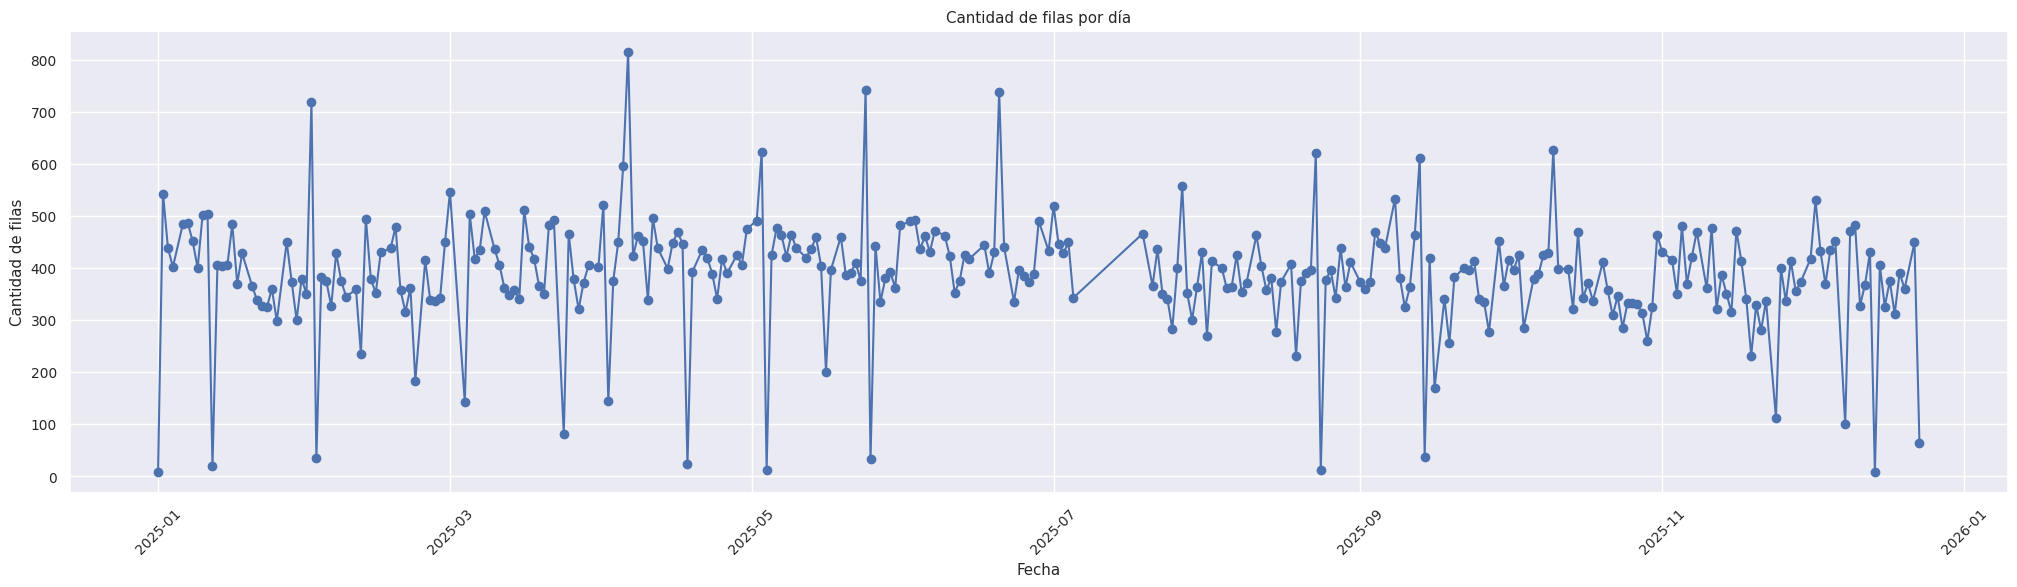

In [ ]:
# Agrupar por fecha completa
conteo_fecha = df.groupby(df['Fecha'].dt.date).size().reset_index(name='Cantidad_filas')

# Graficar línea para ver la evolución diaria
plt.figure(figsize=(25,6))
plt.plot(conteo_fecha['Fecha'], conteo_fecha['Cantidad_filas'], marker='o', linestyle='-')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de filas')
plt.title('Cantidad de filas por día')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


/tmp/ipykernel_2854/3916356132.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Día', y='Cantidad_filas', data=conteo_dia, palette='coolwarm')


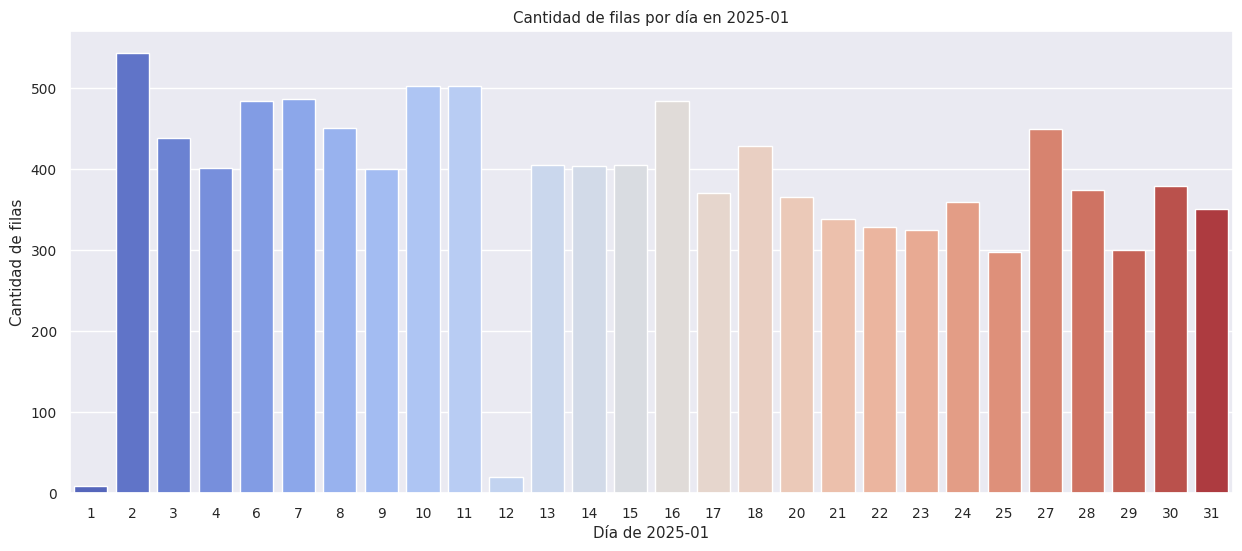

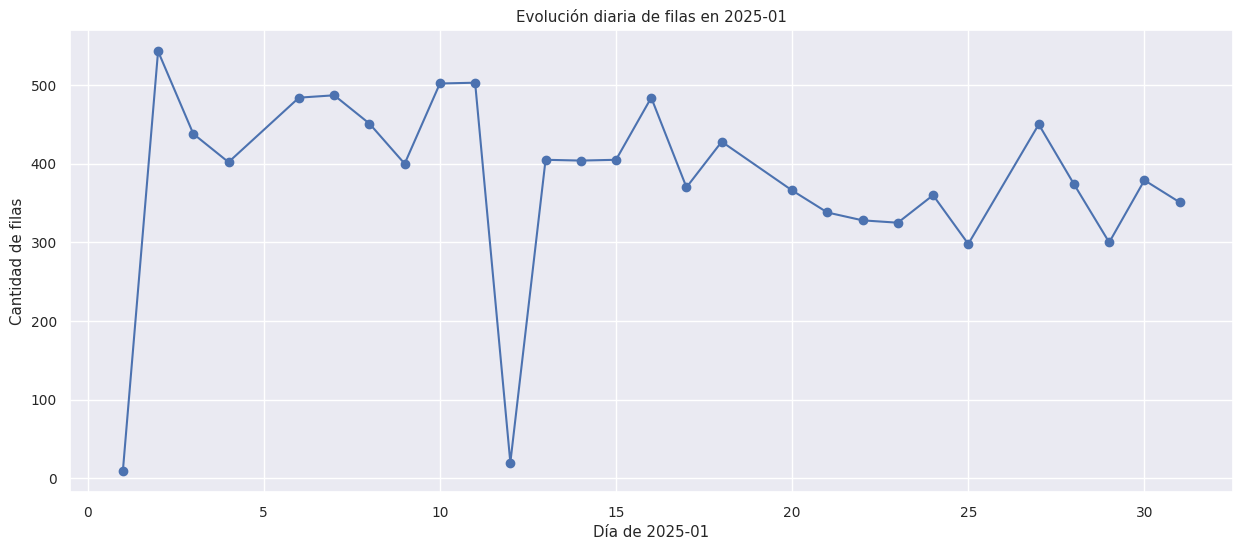

In [ ]:
mes_objetivo = '2025-01' 

df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%y %H.%M.%S', errors='coerce')

df['Mes'] = df['Fecha'].dt.to_period('M')   # Período mensual
df['Día'] = df['Fecha'].dt.day              # Día del mes

# ---------- Filtrar el mes específico ----------
df_mes = df[df['Mes'] == mes_objetivo]

conteo_dia = df_mes.groupby('Día').size().reset_index(name='Cantidad_filas')

plt.figure(figsize=(15,6))
sns.barplot(x='Día', y='Cantidad_filas', data=conteo_dia, palette='coolwarm')
plt.xlabel(f'Día de {mes_objetivo}')
plt.ylabel('Cantidad de filas')
plt.title(f'Cantidad de filas por día en {mes_objetivo}')
plt.show()

plt.figure(figsize=(15,6))
plt.plot(conteo_dia['Día'], conteo_dia['Cantidad_filas'], marker='o', linestyle='-')
plt.xlabel(f'Día de {mes_objetivo}')
plt.ylabel('Cantidad de filas')
plt.title(f'Evolución diaria de filas en {mes_objetivo}')
plt.grid(True)
plt.show()


/tmp/ipykernel_2854/63888539.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Día', y='Cantidad_filas', data=conteo_dia, palette='coolwarm')


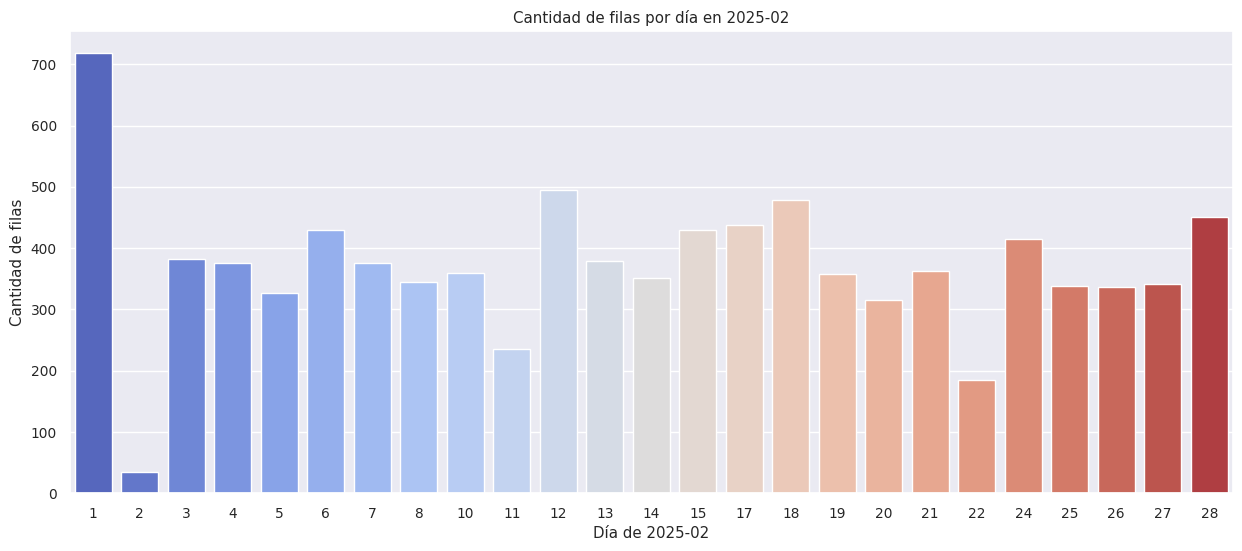

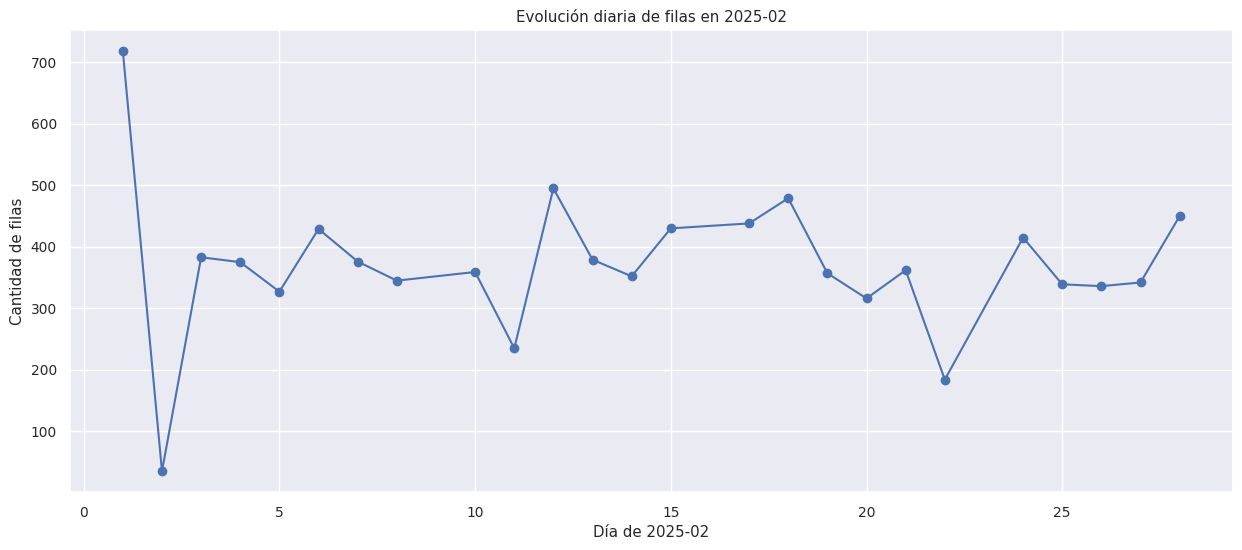

In [ ]:
mes_objetivo = '2025-02' 

df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%y %H.%M.%S', errors='coerce')

df['Mes'] = df['Fecha'].dt.to_period('M')   # Período mensual
df['Día'] = df['Fecha'].dt.day              # Día del mes

# ---------- Filtrar el mes específico ----------
df_mes = df[df['Mes'] == mes_objetivo]

conteo_dia = df_mes.groupby('Día').size().reset_index(name='Cantidad_filas')

plt.figure(figsize=(15,6))
sns.barplot(x='Día', y='Cantidad_filas', data=conteo_dia, palette='coolwarm')
plt.xlabel(f'Día de {mes_objetivo}')
plt.ylabel('Cantidad de filas')
plt.title(f'Cantidad de filas por día en {mes_objetivo}')
plt.show()

plt.figure(figsize=(15,6))
plt.plot(conteo_dia['Día'], conteo_dia['Cantidad_filas'], marker='o', linestyle='-')
plt.xlabel(f'Día de {mes_objetivo}')
plt.ylabel('Cantidad de filas')
plt.title(f'Evolución diaria de filas en {mes_objetivo}')
plt.grid(True)
plt.show()


/tmp/ipykernel_2854/2168840601.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Día', y='Cantidad_filas', data=conteo_dia, palette='coolwarm')


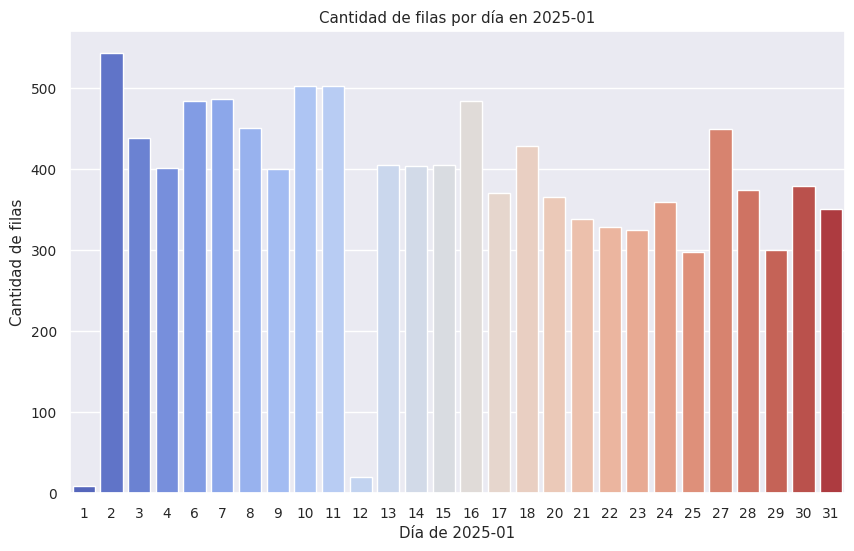

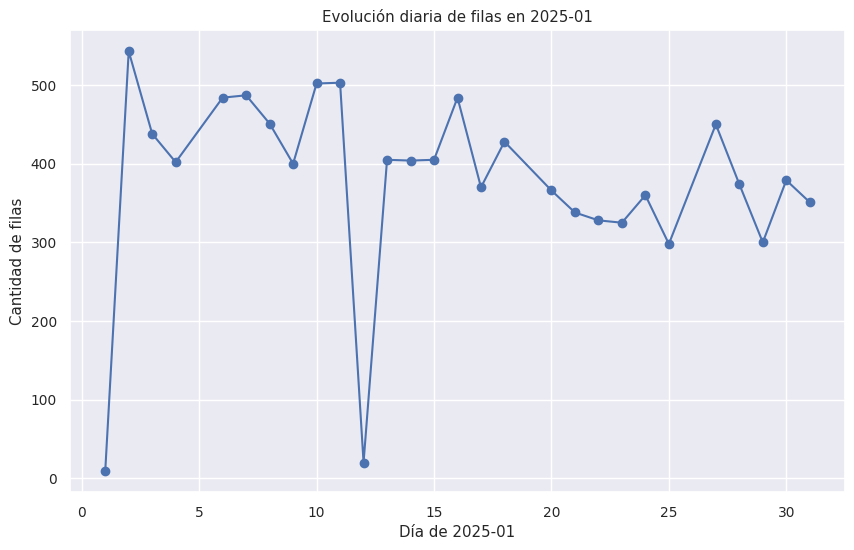

/tmp/ipykernel_2854/2168840601.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Día', y='Cantidad_filas', data=conteo_dia, palette='coolwarm')


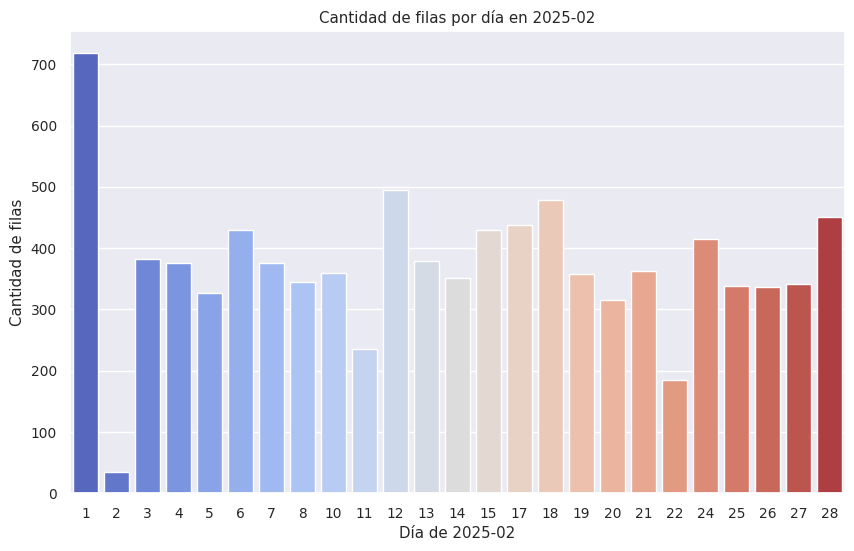

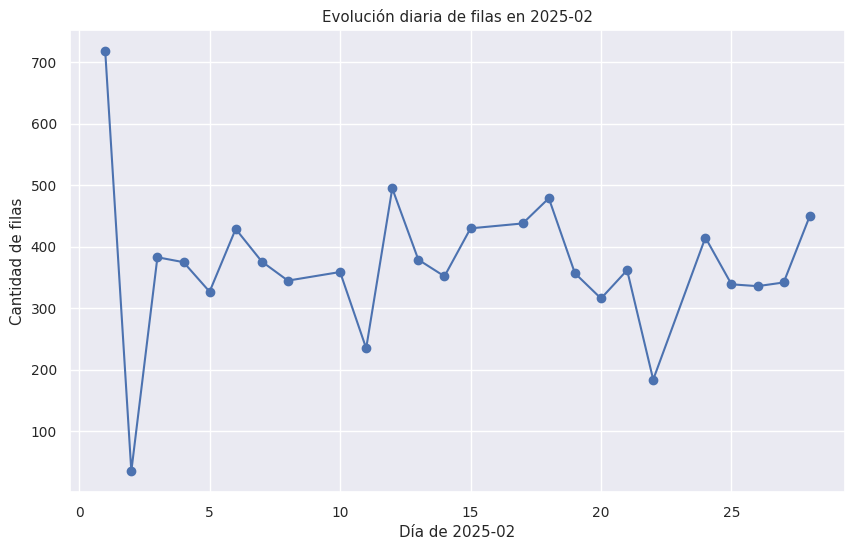

/tmp/ipykernel_2854/2168840601.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Día', y='Cantidad_filas', data=conteo_dia, palette='coolwarm')


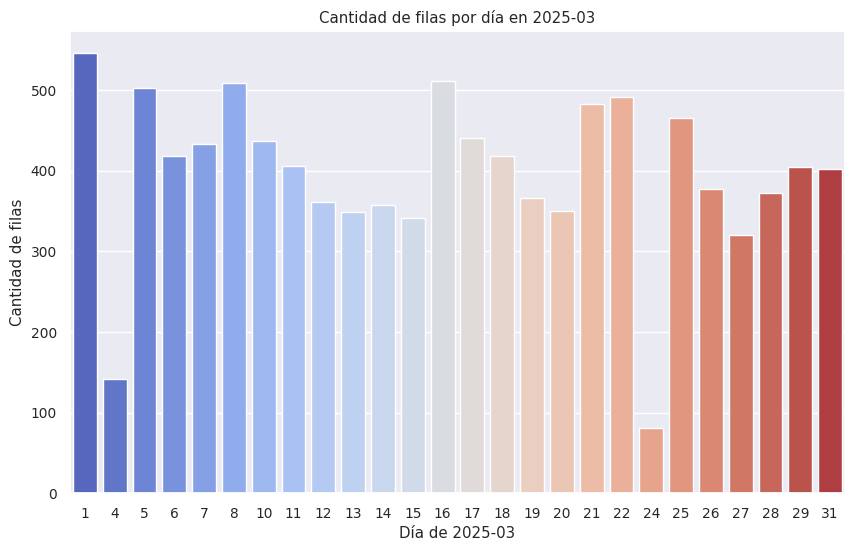

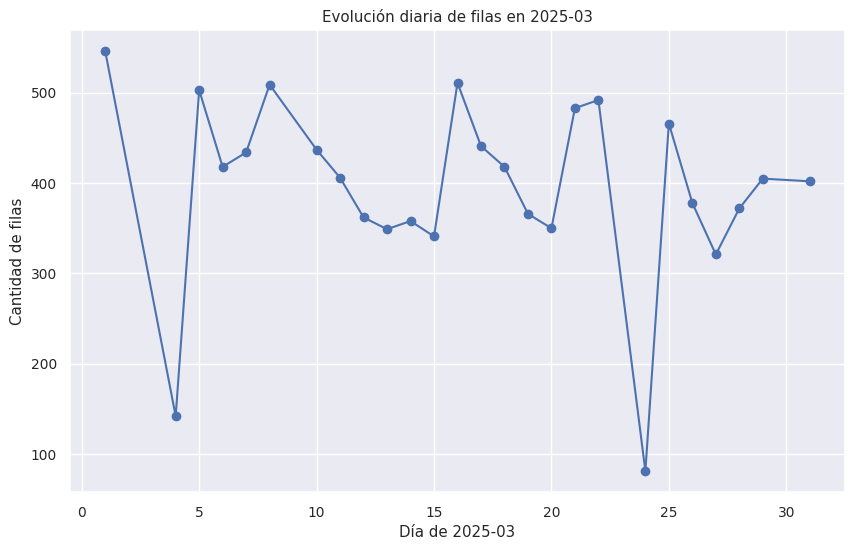

/tmp/ipykernel_2854/2168840601.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Día', y='Cantidad_filas', data=conteo_dia, palette='coolwarm')


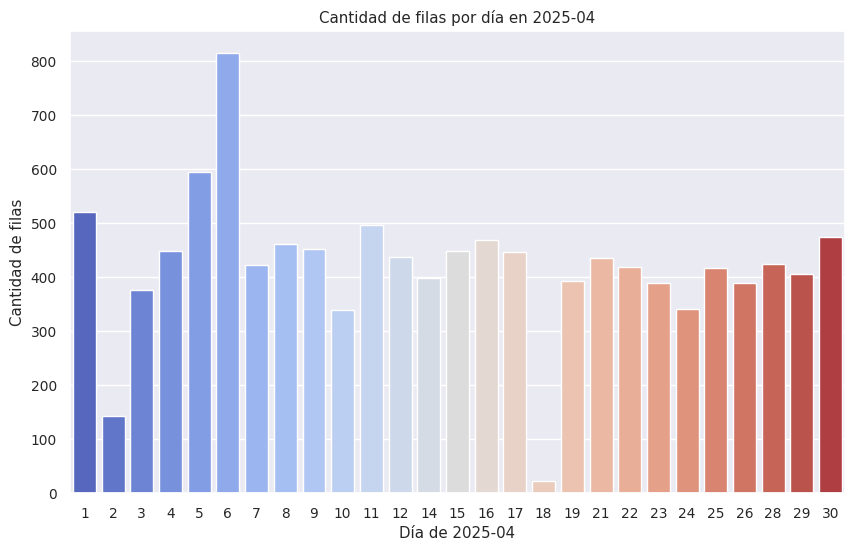

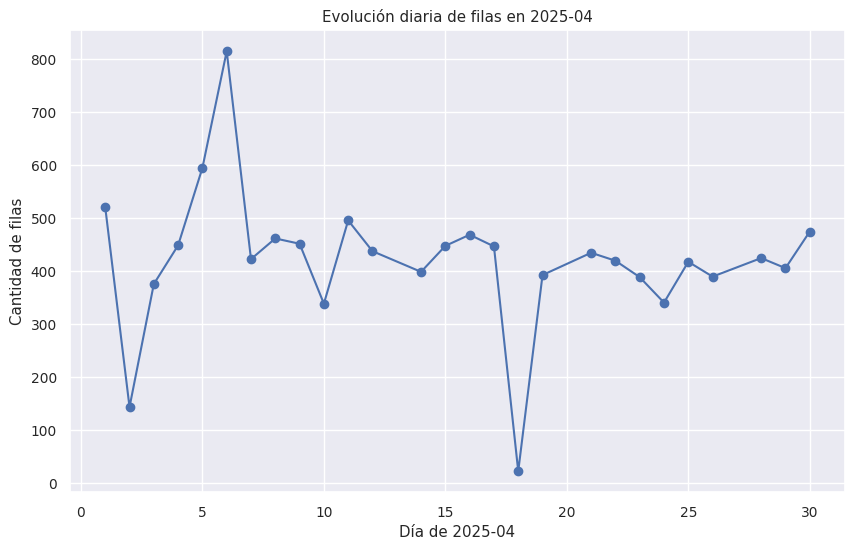

/tmp/ipykernel_2854/2168840601.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Día', y='Cantidad_filas', data=conteo_dia, palette='coolwarm')


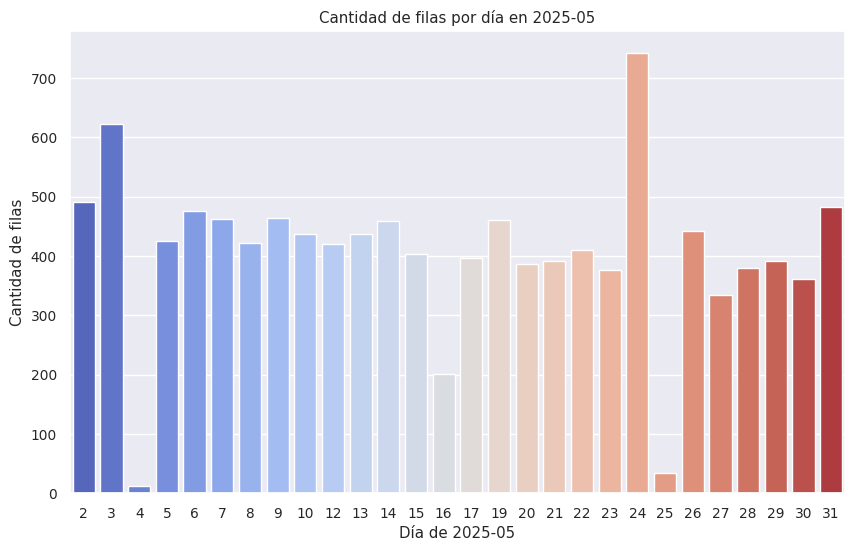

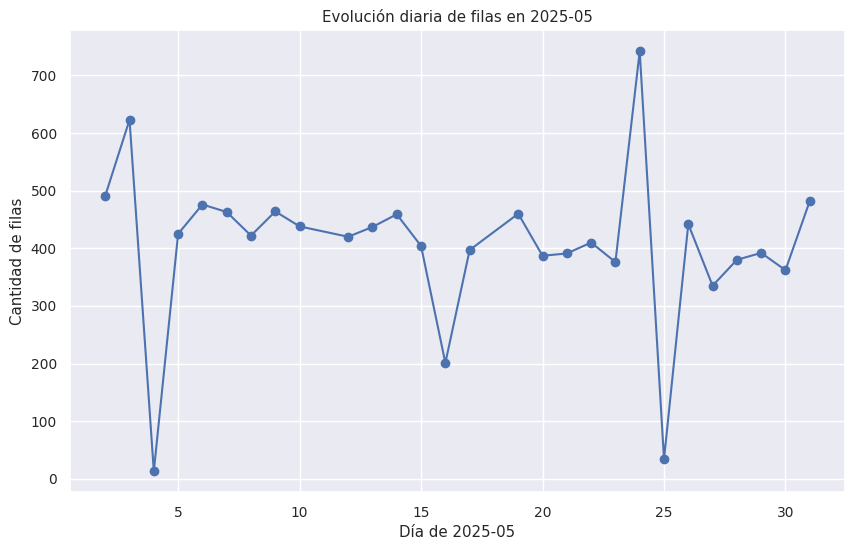

/tmp/ipykernel_2854/2168840601.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Día', y='Cantidad_filas', data=conteo_dia, palette='coolwarm')


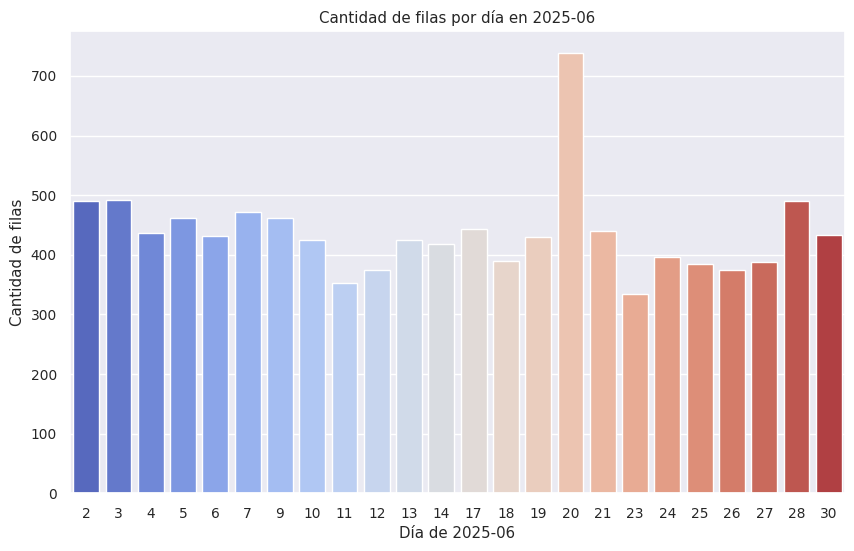

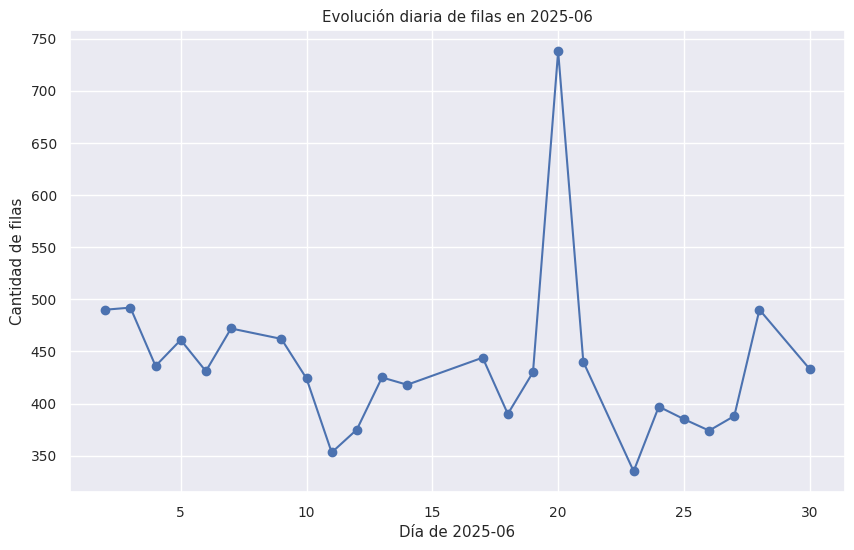

/tmp/ipykernel_2854/2168840601.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Día', y='Cantidad_filas', data=conteo_dia, palette='coolwarm')


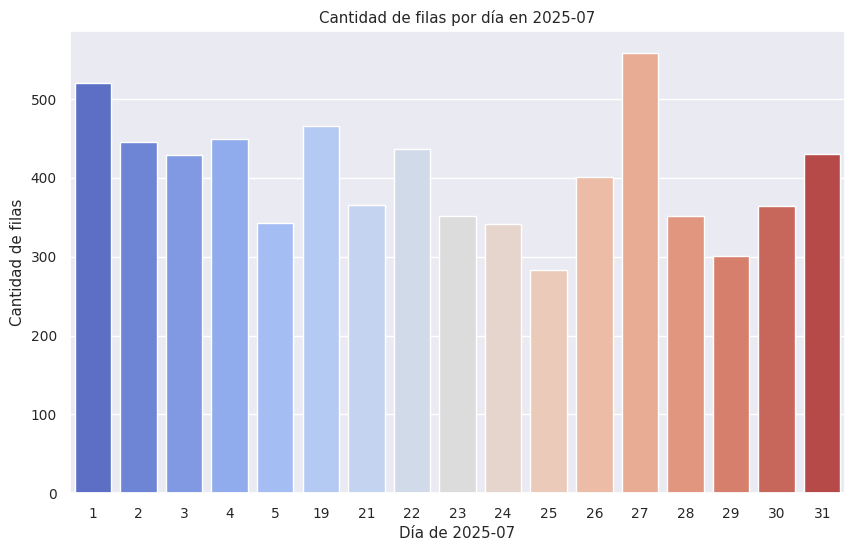

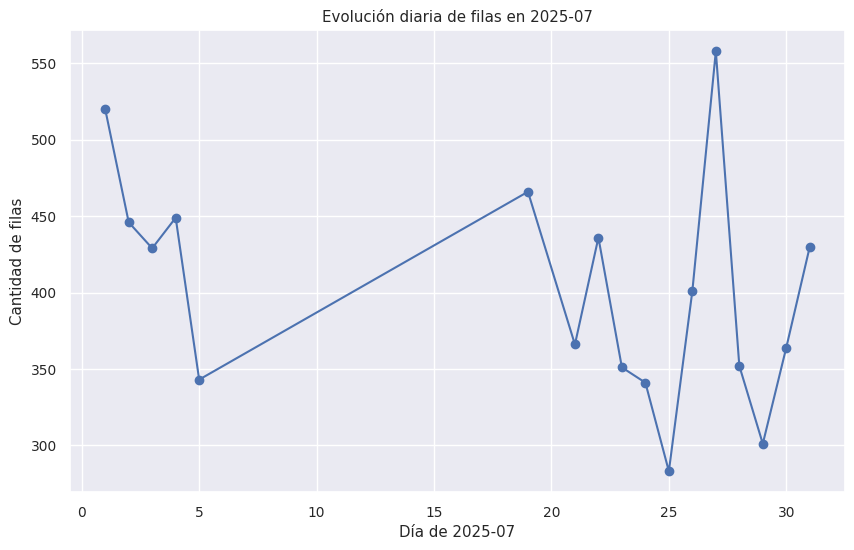

/tmp/ipykernel_2854/2168840601.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Día', y='Cantidad_filas', data=conteo_dia, palette='coolwarm')


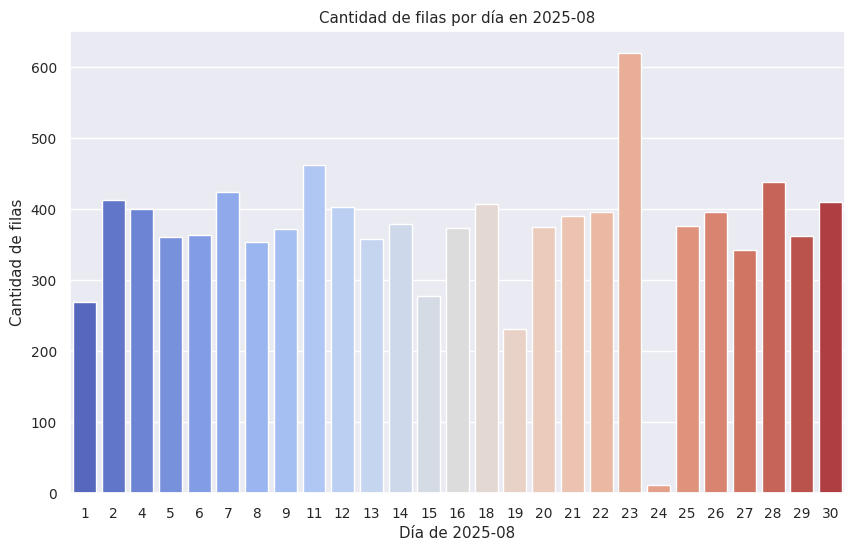

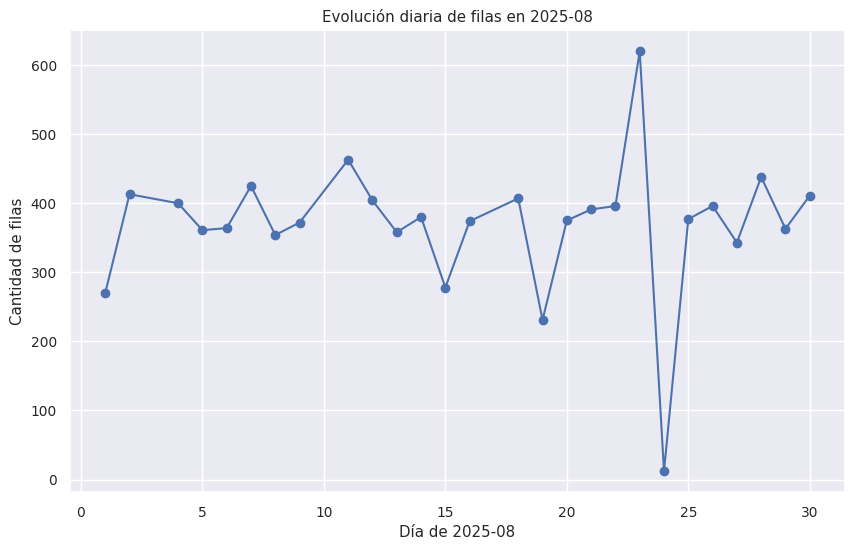

/tmp/ipykernel_2854/2168840601.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Día', y='Cantidad_filas', data=conteo_dia, palette='coolwarm')


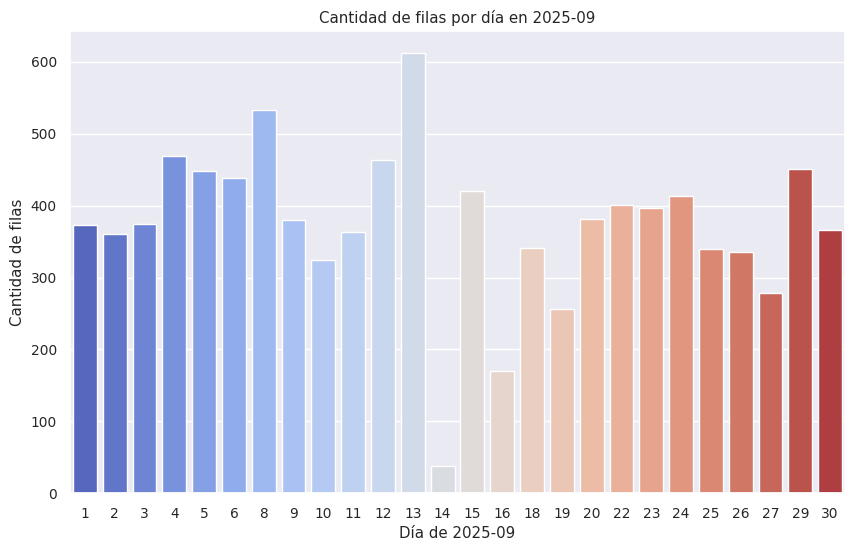

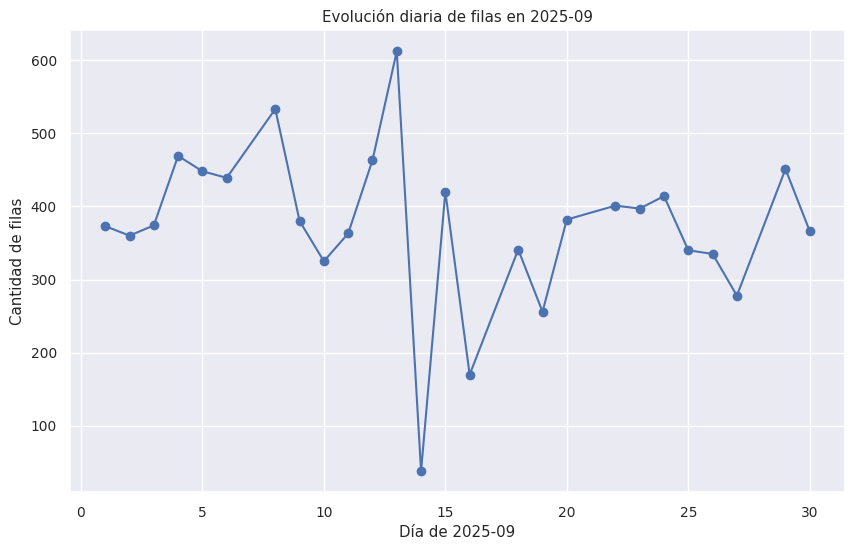

/tmp/ipykernel_2854/2168840601.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Día', y='Cantidad_filas', data=conteo_dia, palette='coolwarm')


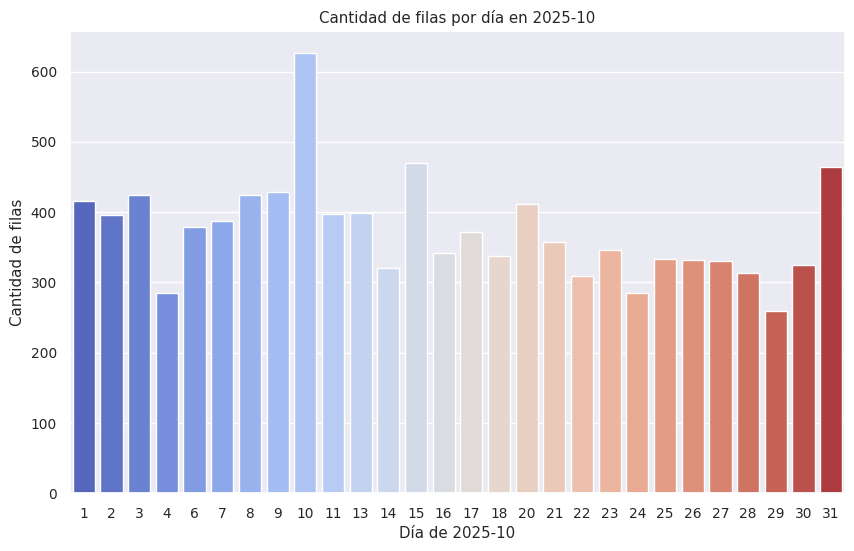

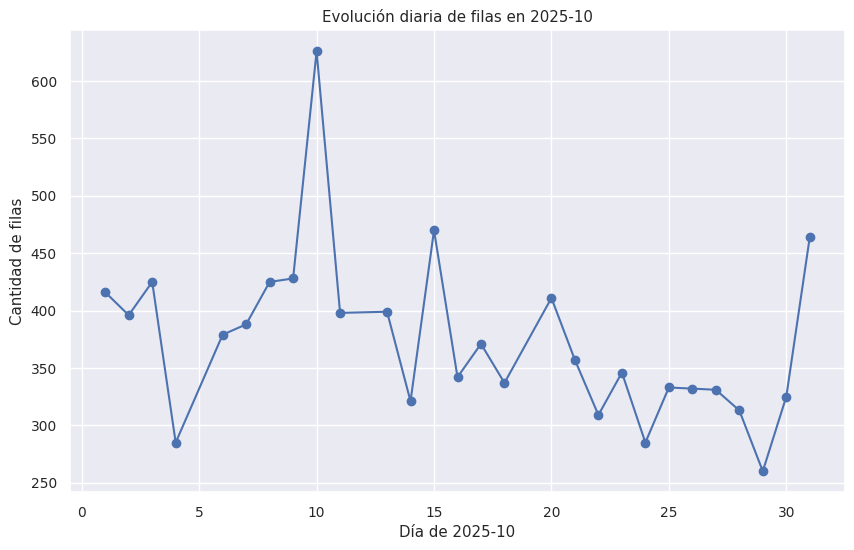

/tmp/ipykernel_2854/2168840601.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Día', y='Cantidad_filas', data=conteo_dia, palette='coolwarm')


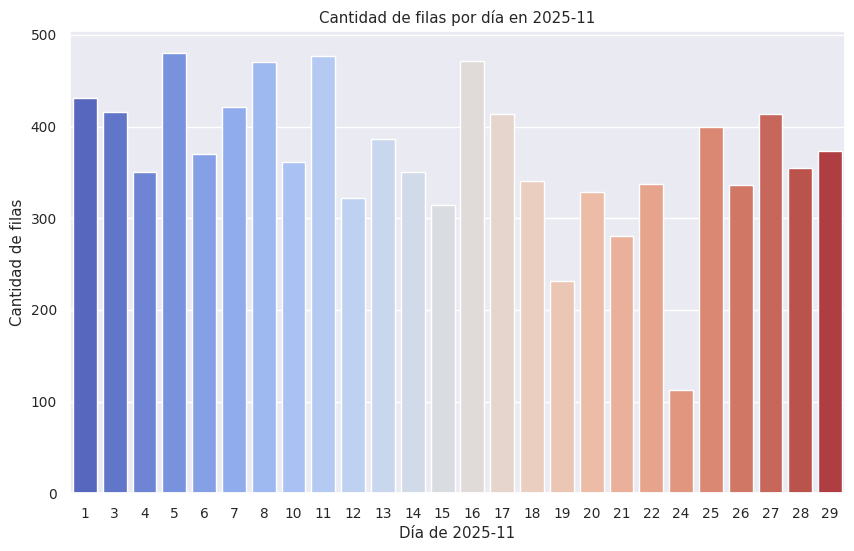

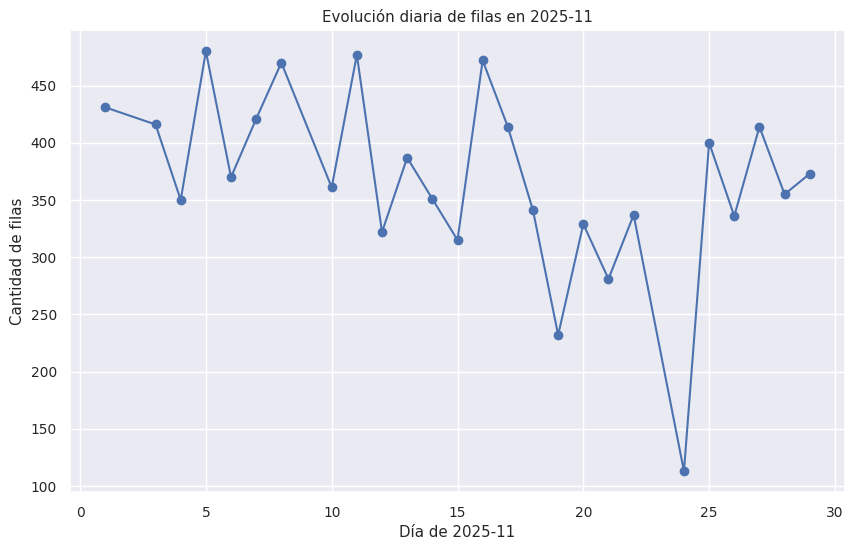

/tmp/ipykernel_2854/2168840601.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Día', y='Cantidad_filas', data=conteo_dia, palette='coolwarm')


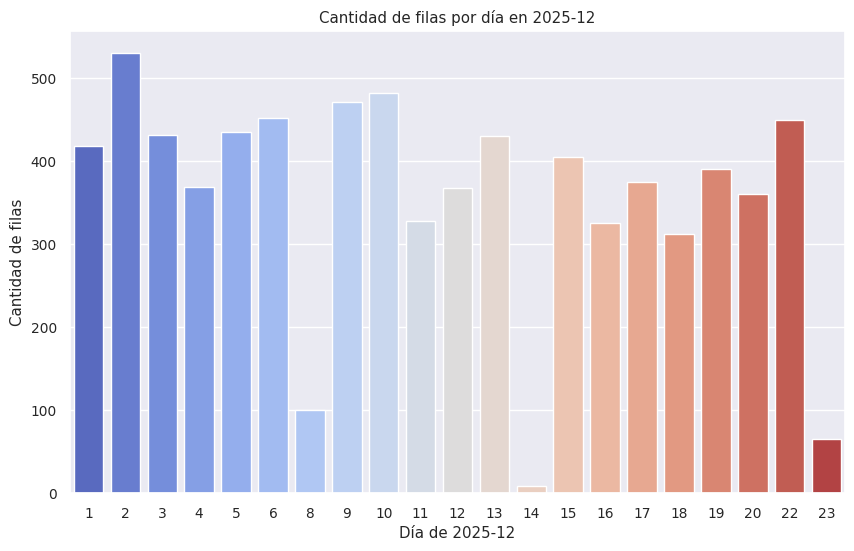

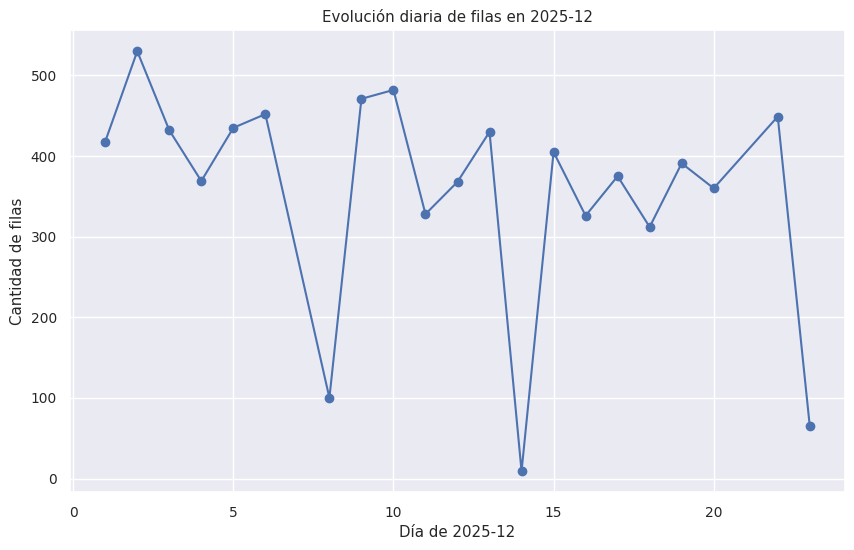

In [ ]:
meses = df['Mes'].sort_values().unique()

# ---------- Recorrer cada mes y generar gráfico ----------
for mes in meses:
    df_mes = df[df['Mes'] == mes]
    conteo_dia = df_mes.groupby('Día').size().reset_index(name='Cantidad_filas')
    
    # ---- Gráfico de barras ----
    plt.figure(figsize=(10,6))
    sns.barplot(x='Día', y='Cantidad_filas', data=conteo_dia, palette='coolwarm')
    plt.xlabel(f'Día de {mes}')
    plt.ylabel('Cantidad de filas')
    plt.title(f'Cantidad de filas por día en {mes}')
    plt.show()
    
    # ---- Gráfico de línea ----
    plt.figure(figsize=(10,6))
    plt.plot(conteo_dia['Día'], conteo_dia['Cantidad_filas'], marker='o', linestyle='-')
    plt.xlabel(f'Día de {mes}')
    plt.ylabel('Cantidad de filas')
    plt.title(f'Evolución diaria de filas en {mes}')
    plt.grid(True)
    plt.show()

/tmp/ipykernel_2854/2129436892.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Día', y='Cantidad_filas', data=conteo_dia, palette='coolwarm', ax=axes[i])
/tmp/ipykernel_2854/2129436892.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Día', y='Cantidad_filas', data=conteo_dia, palette='coolwarm', ax=axes[i])
/tmp/ipykernel_2854/2129436892.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Día', y='Cantidad_filas', data=conteo_dia, palette='coolwarm', ax=axes[i])
/tmp/ipykernel_2854/2129436892.py:25: FutureWarning: 

Passin

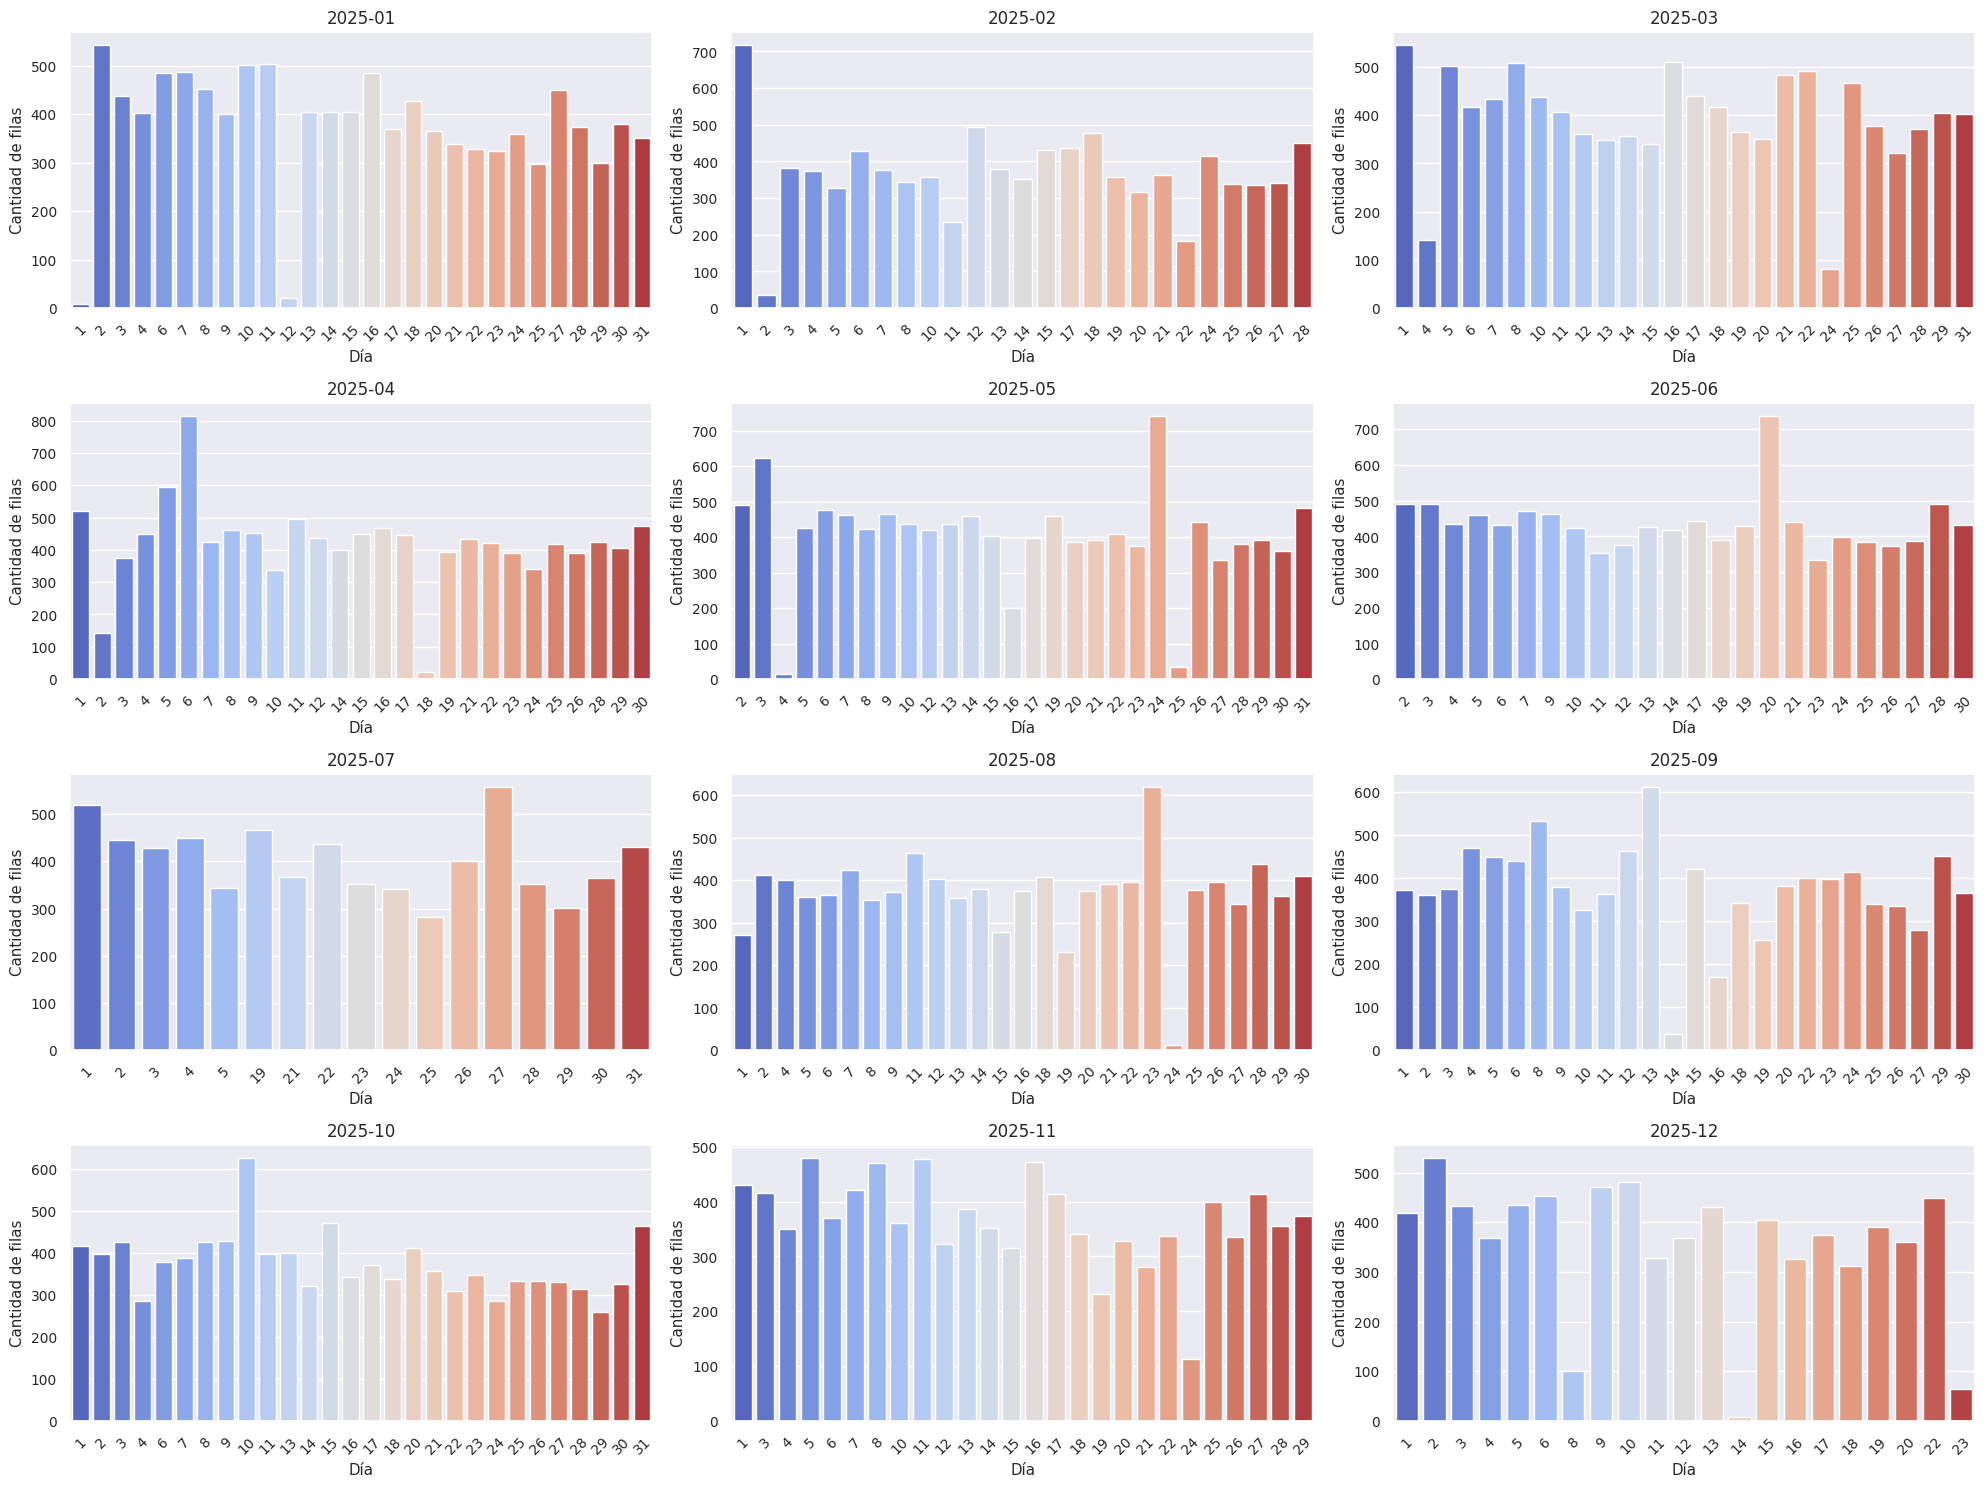

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- Asegurarse de que 'Fecha' sea datetime ----------
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%y %H.%M.%S', errors='coerce')

# ---------- Crear columnas Mes y Día ----------
df['Mes'] = df['Fecha'].dt.to_period('M')
df['Día'] = df['Fecha'].dt.day

# ---------- Obtener todos los meses únicos ----------
meses = df['Mes'].sort_values().unique()
num_meses = len(meses)

# ---------- Configurar figura con subplots ----------
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20,15))  # 4 filas x 3 columnas = 12 meses
axes = axes.flatten()  # Facilita iterar sobre los ejes

# ---------- Recorrer cada mes y graficar ------
for i, mes in enumerate(meses):
    df_mes = df[df['Mes'] == mes]
    conteo_dia = df_mes.groupby('Día').size().reset_index(name='Cantidad_filas')
    
    sns.barplot(x='Día', y='Cantidad_filas', data=conteo_dia, palette='coolwarm', ax=axes[i])
    axes[i].set_title(f'{mes}', fontsize=12)
    axes[i].set_xlabel('Día')
    axes[i].set_ylabel('Cantidad de filas')
    axes[i].tick_params(axis='x', rotation=45)

# ---------- Ajustar layout ----------
plt.tight_layout()
plt.show()


- hay fluctuaciones que se nota, hay días con picos cercanos a los 800, mientras que otros apenas superan los 100.
- CON MAS ACTIVIDAD ENERO, MARZO Y DICIEMBRE - COMPRAS DE VERANO, COMPRAS DE INVIERNO Y COMPRAS DE FIN DE AÑO.
- CON MENOS JUNIO Y AGOSTO - MESES DEL INVIERNO CON MUCHO FRIO Y VACACIONES ESCOLARES DE INVIERNO

In [ ]:
ventas_mensual = df.groupby('Mes').size().reset_index(name='Cantidad_filas')
print(ventas_mensual)

        Mes  Cantidad_filas
0   2025-01           10604
1   2025-02            9256
2   2025-03           10291
3   2025-04           11388
4   2025-05           11326
5   2025-06           10483
6   2025-07            6836
7   2025-08            9976
8   2025-09            9728
9   2025-10           10472
10  2025-11            9548
11  2025-12            7507


In [ ]:
ventas_diarias = df.groupby('Día').size().reset_index(name='Cantidad_filas')
print(ventas_diarias)

    Día  Cantidad_filas
0     1            4222
1     2            3848
2     3            4388
3     4            4139
4     5            4378
5     6            5057
6     7            3889
7     8            4071
8     9            3429
9    10            4293
10   11            4022
11   12            3667
12   13            4181
13   14            3489
14   15            3916
15   16            3349
16   17            3697
17   18            3476
18   19            3582
19   20            4014
20   21            3844
21   22            4162
22   23            3204
23   24            3501
24   25            3673
25   26            3720
26   27            3760
27   28            3949
28   29            3251
29   30            3115
30   31            2129


/tmp/ipykernel_2854/1806758902.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Día', y='Cantidad_filas', data=ventas_diarias, palette='viridis')


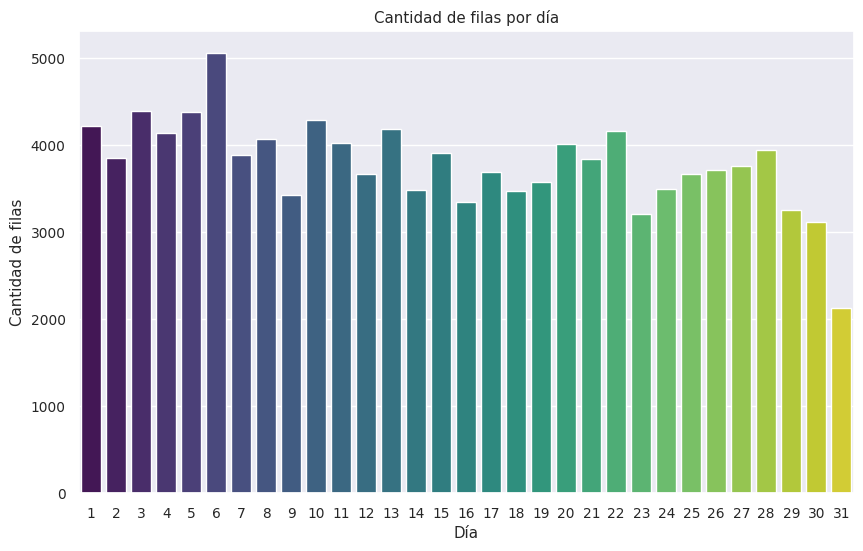

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x='Día', y='Cantidad_filas', data=ventas_diarias, palette='viridis')
plt.xlabel('Día')
plt.ylabel('Cantidad de filas')
plt.title('Cantidad de filas por día')
plt.show()

In [ ]:
df.columns

Index(['Fecha', 'Tipo Mov.', 'Fac. Tipo', 'Fac. Suc.', 'Fac. Nun.',
       'Tipo Pago', 'Cant.', 'Precio', 'Producto', 'Sub. Total', 'Rubro',
       'Cobertura', 'Ajustes', 'Desc. Adic.', 'Total. Cliente', 'IVA',
       'Tasa Iva', 'Total Gravado', 'Total sin Gravar', 'Mes', 'presentacion',
       'Día'],
      dtype='object')

In [ ]:
ventas_diarias = df.groupby('Día')['Total. Cliente'].sum().reset_index(name='Total_ventas')
pd.set_option('display.float_format', '{:,.0f}'.format)
ventas_diarias


,Día,Total_ventas
0,1,"38,728,384"
1,2,"37,089,413"
2,3,"41,208,669"
3,4,"39,445,657"
4,5,"42,595,946"
5,6,"46,531,314"
6,7,"35,048,200"
7,8,"38,400,256"
8,9,"33,146,664"
9,10,"41,618,677"


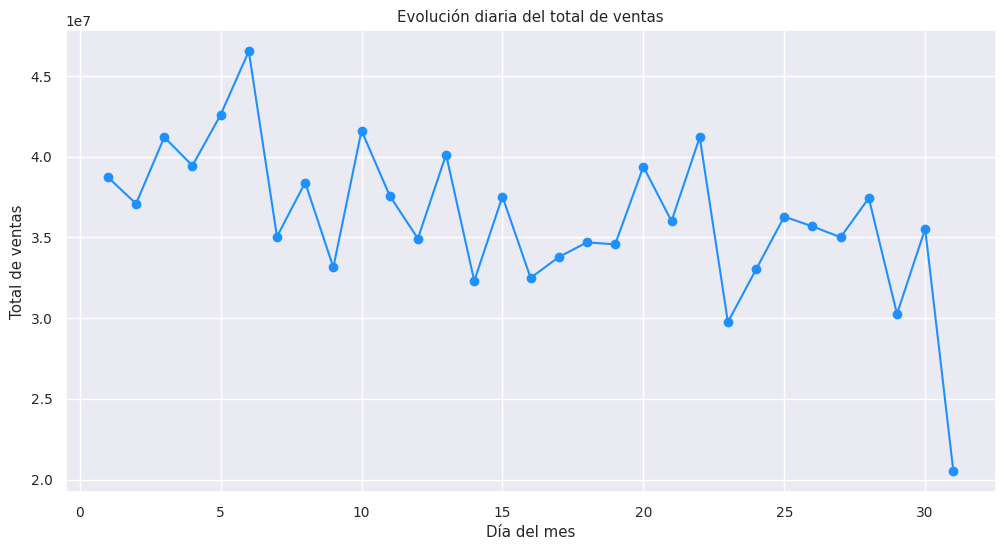

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(ventas_diarias['Día'], ventas_diarias['Total_ventas'], marker='o', linestyle='-', color='dodgerblue')
plt.xlabel('Día del mes')
plt.ylabel('Total de ventas')
plt.title('Evolución diaria del total de ventas')
plt.grid(True)

In [ ]:
ventas_mensualestot = df.groupby('Mes')['Total. Cliente'].sum().reset_index(name='Total_ventas')
pd.set_option('display.float_format', '{:,.0f}'.format)
ventas_mensualestot


,Mes,Total_ventas
0,2025-01,"90,385,211"
1,2025-02,"77,988,225"
2,2025-03,"89,176,096"
3,2025-04,"104,763,261"
4,2025-05,"101,645,409"
5,2025-06,"94,722,856"
6,2025-07,"67,661,263"
7,2025-08,"96,828,669"
8,2025-09,"98,123,103"
9,2025-10,"109,894,497"


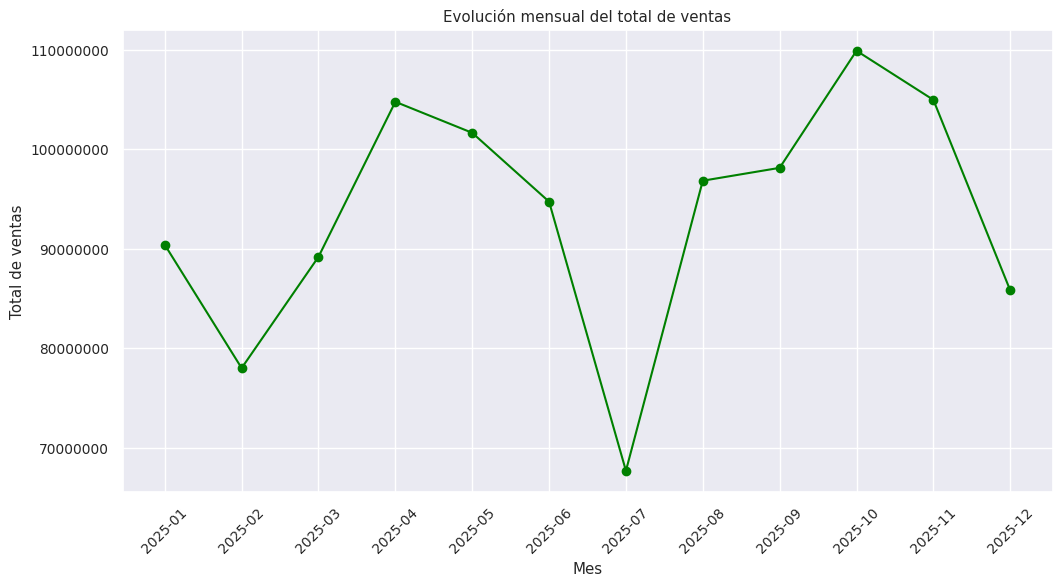

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(ventas_mensualestot['Mes'].astype(str), ventas_mensualestot['Total_ventas'],
         marker='o', linestyle='-', color='green')
plt.xlabel('Mes')
plt.ylabel('Total de ventas')
plt.title('Evolución mensual del total de ventas')
plt.grid(True)

# ---- Evitar notación científica en el eje Y ----
plt.ticklabel_format(style='plain', axis='y')

plt.xticks(rotation=45)  # Rotar etiquetas si los meses se solapan
plt.show()


,Día,Total_ventas
0,1,"38,728,384"
1,2,"37,089,413"
2,3,"41,208,669"
3,4,"39,445,657"
4,5,"42,595,946"
5,6,"46,531,314"
6,7,"35,048,200"
7,8,"38,400,256"
8,9,"33,146,664"
9,10,"41,618,677"


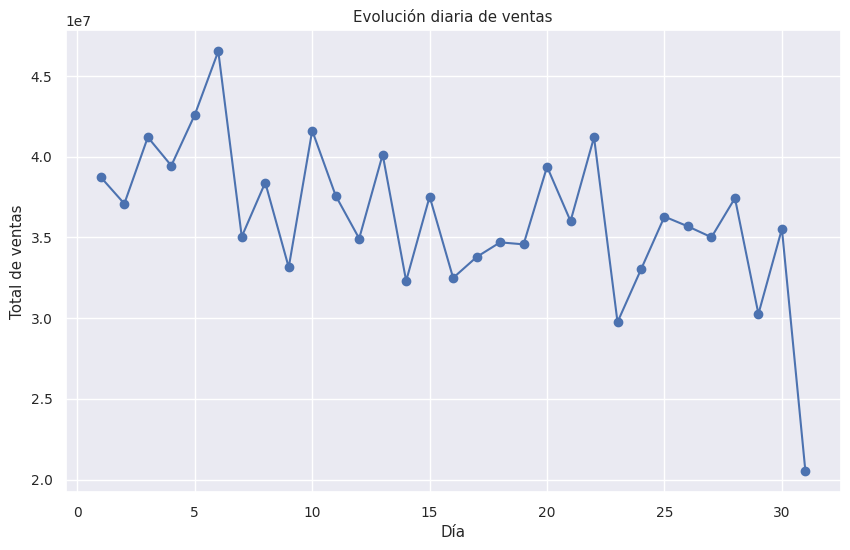

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(ventas_diarias['Día'], ventas_diarias['Total_ventas'], marker='o', linestyle='-')
plt.xlabel('Día')
plt.ylabel('Total de ventas')
plt.title('Evolución diaria de ventas')
plt.grid(True)
plt.show()
